In [19]:
import glob as glob_module

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import json

%config InlineBackend.figure_format='retina'

# Create figures from VirBench benchmarking results

In [20]:
# Plotting configurations
import os

AGENT_REGISTRY = [
    ("Claude", "../results/claude", "claude_"),
    ("Biomni", "../results/biomni", "biomni_"),
    ("Edison", "../results/edison_analysis", ""),
    ("GPT", "../results/gpt", "gpt_"),
]

# AGENT_BASE_COLORS = {
#     "Claude": "#f3f3f3",
#     "Biomni": "#c2c2c2",
#     "Edison": "#9b9b9b",
#     "GPT": "#7c7c7c",
#     "gget virus": "#EE6C4D",
# }

AGENT_BASE_COLORS = {
    "Claude": "#c2c2c2",
    "Biomni": "#c2c2c2",
    "Edison": "#c2c2c2",
    "GPT": "#c2c2c2",
    "gget virus": "#EE6C4D",
}

def discover_sources(rerun=True, file_type="summary"):
    ext = ".csv" if file_type == "summary" else ".json"
    rerun_sfx = "_rerun_*" if rerun else ""
    sources = {}
    for agent, base_dir, prefix in AGENT_REGISTRY:
        if not os.path.isdir(base_dir):
            continue
        subdirs = sorted(
            e for e in os.listdir(base_dir)
            if os.path.isdir(os.path.join(base_dir, e)) and e != "pilot" and not e.startswith(".")
        )
        for model in subdirs:
            label = f"{agent} ({model})"
            d = f"{base_dir}/{model}"
            sources[label] = (f"{d}/{prefix}benchmark_{file_type}_*{rerun_sfx}{ext}", "_gv_")
            sources[f"{label} + gget"] = (f"{d}/{prefix}benchmark_{file_type}_gv_*{rerun_sfx}{ext}", None)
    gget_dir = "../results/gget_virus"
    if os.path.isdir(gget_dir):
        sources["gget virus"] = (f"{gget_dir}/gget_direct_benchmark_{file_type}_*{rerun_sfx}{ext}", None)
    return sources


def get_agent_base(tech_name):
    if tech_name == "gget virus":
        return "gget virus"
    name = tech_name.replace(" + gget", "")
    for base in AGENT_BASE_COLORS:
        if base != "gget virus" and name.startswith(base):
            return base
    return name.split(" (")[0]


FONTSIZE = 12

FIGSIZE = (8, 2)


In [21]:
# Model display order and naming

MODEL_DISPLAY = [
    ("Claude (claude-sonnet-4-20250514)", "Claude Sonnet 4"),
    ("Biomni (claude-sonnet-4-20250514)", "Biomni"),
    ("Edison (2026-02-26)", "Edison Analysis"),
    ("GPT (gpt-5.2-pro)", "GPT 5.2 pro"),
    ("Claude (claude-opus-4-7)", "Claude Opus 4.7"),
    ("GPT (gpt-5.5)", "GPT 5.5"),
]

In [22]:
# Load pathogen mapping from benchmark configs
import yaml
with open("../config.yaml") as _f:
    _config = yaml.safe_load(_f)
configs = pd.read_csv(f"../{_config["benchmark_csv"]}")
configs = configs[pd.to_numeric(configs["query_id"], errors="coerce").notna()]
configs["query_id"] = configs["query_id"].astype(int)
pathogen_map = configs.set_index("query_id")["pathogen"].to_dict()

rerun = True

# When True, runs with missing retrieved_count but no explicit error are treated as 0.
# When False, they are treated as NaN (excluded from metrics, counted as errors).
NONE_TREATED_AS_ZERO = False

SOURCES = discover_sources(rerun=rerun, file_type="summary")

# Apply display names and ordering from MODEL_DISPLAY
_renamed = {}
for _discovered, _display in MODEL_DISPLAY:
    if _discovered in SOURCES:
        _renamed[_display] = SOURCES[_discovered]
    _gget_key = f"{_discovered} + gget"
    if _gget_key in SOURCES:
        _renamed[f"{_display} + gget"] = SOURCES[_gget_key]
if "gget virus" in SOURCES:
    _renamed["gget virus"] = SOURCES["gget virus"]
SOURCES = _renamed

TECHNOLOGIES = list(SOURCES.keys())

COLORS = {}
XTICKLABEL_COLORS = {}
HATCH = {}
for t in TECHNOLOGIES:
    base = get_agent_base(t)
    COLORS[t] = AGENT_BASE_COLORS.get(base, "#000000")
    XTICKLABEL_COLORS[t] = AGENT_BASE_COLORS[base] if base == "gget virus" else "black"
    HATCH[t] = "//" if "+ gget" in t else None

In [23]:
def load_benchmark(file_pattern, exclude_substring=None, return_path=False):
    """Load the most recent benchmark CSV matching the glob pattern.

    Runs with an explicit error (non-empty 'error' column) are recorded as np.nan.
    Handling of runs where 'retrieved_count' is missing/None but there is no error
    depends on NONE_TREATED_AS_ZERO: if True, they are set to 0; if False, to np.nan.

    Returns (query_ids, expected, runs, durations, n_errors, n_nones, file_path) if return_path else previous tuple.
    """
    files = sorted(glob_module.glob(file_pattern))
    if exclude_substring:
        files = [f for f in files if exclude_substring not in f]
    if not files:
        raise FileNotFoundError(f"No files matching {file_pattern}")
    file_path = files[-1]
    df = pd.read_csv(file_path)

    query_ids = sorted(df["query_id"].unique())
    n_runs = df["run_number"].nunique()

    expected = np.full(len(query_ids), np.nan)
    runs = np.full((len(query_ids), n_runs), np.nan)
    durations = np.full((len(query_ids), n_runs), np.nan)
    n_errors = 0  # runs with explicit error message
    n_nones = 0   # runs with missing retrieved_count but no error

    for i, qid in enumerate(query_ids):
        group = df[df["query_id"] == qid].sort_values("run_number")
        expected[i] = group["expected_count"].iloc[0]
        for _, row in group.iterrows():
            j = int(row["run_number"]) - 1

            # Check if this run had an explicit error
            error_val = row.get("error", "")
            has_error = (
                error_val is not None
                and not pd.isnull(error_val)
                and str(error_val).strip() != ""
            )

            if has_error:
                # Real error: exclude from all computations
                runs[i, j] = np.nan
                durations[i, j] = np.nan
                n_errors += 1
                continue

            # No error — handle retrieved_count
            retrieved = row.get("retrieved_count", np.nan)
            retrieved_missing = (
                pd.isnull(retrieved)
                or retrieved is None
                or (isinstance(retrieved, str) and retrieved.lower() == "error")
                or retrieved == ""
            )
            if retrieved_missing:
                n_nones += 1
                runs[i, j] = 0 if NONE_TREATED_AS_ZERO else np.nan
            else:
                runs[i, j] = retrieved

            # Duration (keep as-is for non-error runs)
            dur = row.get("duration_seconds", np.nan)
            if pd.isnull(dur) or dur is None or (isinstance(dur, str) and dur.lower() == "error") or dur == "":
                durations[i, j] = np.nan
            else:
                durations[i, j] = dur

    if return_path:
        return query_ids, expected, runs, durations, n_errors, n_nones, file_path
    else:
        return query_ids, expected, runs, durations, n_errors, n_nones

data = {}
loaded_paths = {}
for name in TECHNOLOGIES:
    pattern, exclude = SOURCES[name]
    try:
        # Try to load rerun summary files first (original pattern as passed in)
        qids, exp, runs, dur, n_errors, n_nones, file_path = load_benchmark(pattern, exclude_substring=exclude, return_path=True)
    except FileNotFoundError:
        # If rerun summary files are not found, fall back to original (non-rerun) summary files
        # Try to remove "rerun" from the glob, if present (basic handling)
        alt_pattern = pattern.replace("_rerun_", "_")
        try:
            print(f"[INFO] Rerun files not found for {name}. Falling back to non-rerun benchmark summary files.")
            qids, exp, runs, dur, n_errors, n_nones, file_path = load_benchmark(alt_pattern, exclude_substring=exclude, return_path=True)
        except FileNotFoundError:
            raise FileNotFoundError(f"No benchmark summary files found for {name}: tried {pattern} and {alt_pattern}")
    data[name] = {
        "query_ids": qids, "expected": exp, "runs": runs, "durations": dur,
        "n_errors": n_errors, "n_nones": n_nones,
    }
    loaded_paths[name] = file_path

# Print file paths that were loaded for each model
print("\nBenchmark summary files loaded per model:")
for model, path in loaded_paths.items():
    print(f"  {model}: {path}")

[INFO] Rerun files not found for Claude Opus 4.7. Falling back to non-rerun benchmark summary files.
[INFO] Rerun files not found for Claude Opus 4.7 + gget. Falling back to non-rerun benchmark summary files.

Benchmark summary files loaded per model:
  Claude Sonnet 4: ../results/claude/claude-sonnet-4-20250514/claude_benchmark_summary_20260226_211231_rerun_20260302_120413.csv
  Claude Sonnet 4 + gget: ../results/claude/claude-sonnet-4-20250514/claude_benchmark_summary_gv_20260227_112923_rerun_20260302_123424.csv
  Biomni: ../results/biomni/claude-sonnet-4-20250514/biomni_benchmark_summary_20260226_211315_rerun_20260302_095413.csv
  Biomni + gget: ../results/biomni/claude-sonnet-4-20250514/biomni_benchmark_summary_gv_20260227_113135_rerun_20260302_105027.csv
  Edison Analysis: ../results/edison_analysis/2026-02-26/benchmark_summary_20260226_211213_rerun_20260301_213842.csv
  Edison Analysis + gget: ../results/edison_analysis/2026-02-26/benchmark_summary_gv_20260227_113028_rerun_202603

In [24]:
def accuracy_per_case(expected, runs):
    """
    Fraction of runs that exactly match expected, **ignoring missing/errored runs (np.nan)**.

    For each case, missing runs (np.nan) are excluded from the calculation.
    If all runs are missing for a case, the result will be np.nan for that case.
    """
    matches = runs == expected[:, None]
    # Exclude np.nan in runs (missing/errored)
    not_nan = ~np.isnan(runs)
    # Only consider where runs are NOT nan
    fraction_match = np.full(runs.shape[0], np.nan)
    for i in range(runs.shape[0]):
        valid = not_nan[i]
        n_valid = np.sum(valid)
        if n_valid == 0:
            fraction_match[i] = np.nan
        else:
            fraction_match[i] = np.sum(matches[i][valid]) / n_valid
    return fraction_match

def stability_per_case(runs, eps=1e-6):
    """
    Stability score: 1 / (1 + CV). Higher is better; never exceeds 1.

    **Missing/errored runs (np.nan) are ignored when calculating mean and std.**
    If all runs are missing for a case, stability will be np.nan for that case.

    When std==0, stability=1/(1+0)=1 (fully stable).
    As std increases, stability decreases. When mean is very close to zero,
    the score uses the absolute std (not divided by mean).
    Scores are always in (0, 1], never above 1.
    """
    mean = np.nanmean(runs, axis=1)
    std = np.nanstd(runs, axis=1)
    stability = np.full(len(mean), np.nan)
    near_zero = mean < eps
    all_nan = np.all(np.isnan(runs), axis=1)
    # Only calculate if there are non-nan values
    stability[~all_nan & near_zero] = 1 / (1 + std[~all_nan & near_zero])
    stability[~all_nan & ~near_zero] = 1 / (1 + std[~all_nan & ~near_zero] / mean[~all_nan & ~near_zero])
    # If all runs are nan, result stays nan as initialized
    return stability

def mean_absolute_error_per_case(expected, runs):
    """
    Mean absolute error between runs and expected, **ignoring missing/errored runs (np.nan)**.
    If all runs are missing for a case, the result is np.nan for that case.
    """
    return np.nanmean(np.abs(runs - expected[:, None]), axis=1)

def mean_relative_error_per_case(expected, runs, eps=1e-6):
    """
    Mean relative error, **ignoring missing/errored runs (np.nan)**.
    Relative to expected (with small epsilon for stability).
    If all runs are missing for a case, the result is np.nan for that case.
    """
    denom = np.maximum(expected[:, None], eps)
    return np.nanmean(np.abs(runs - expected[:, None]) / denom, axis=1)

def overall_score(accuracy, stability, mean_relative_error):
    """
    Composite benchmark score in [0, 1]. Higher is better.
    If any component is np.nan (e.g. due to all missing runs for a case), overall_score is np.nan for that case.
    """
    return accuracy * stability * np.exp(-mean_relative_error)

# Compute all metrics for every technology
metrics = {}
print(f"NONE_TREATED_AS_ZERO = {NONE_TREATED_AS_ZERO}\n")
print("Technology stats summary:")
for name in TECHNOLOGIES:
    d = data[name]
    total_queries = d["runs"].shape[0]
    total_possible = d["runs"].size
    n_nan_runs = int(np.sum(np.isnan(d["runs"])))
    total_valid = total_possible - n_nan_runs
    n_errors = d["n_errors"]
    n_nones = d["n_nones"]

    print(f"  {name}:")
    print(f"    Total queries: {total_queries}, Total runs: {total_possible}")
    if NONE_TREATED_AS_ZERO:
        print(f"    Errors (excluded): {n_errors}")
        print(f"    None results (counted as 0): {n_nones}")
        print(f"    Runs used in metrics: {total_valid}/{total_possible}")
    else:
        total_excluded = n_errors + n_nones
        print(f"    Errors (excluded): {total_excluded}  ({n_errors} explicit + {n_nones} None)")
        print(f"    Runs used in metrics: {total_valid}/{total_possible}")

    acc = accuracy_per_case(d["expected"], d["runs"])
    stab = stability_per_case(d["runs"])
    mae = mean_absolute_error_per_case(d["expected"], d["runs"])
    mre = mean_relative_error_per_case(d["expected"], d["runs"])
    scr = overall_score(acc, stab, mre)
    mean_dur = np.nanmean(d["durations"], axis=1)
    metrics[name] = {
        "accuracy": acc,
        "stability": stab,
        "mae": mae,
        "mre": mre,
        "score": scr,
        "duration": mean_dur,
    }

NONE_TREATED_AS_ZERO = False

Technology stats summary:
  Claude Sonnet 4:
    Total queries: 120, Total runs: 360
    Errors (excluded): 0  (0 explicit + 0 None)
    Runs used in metrics: 360/360
  Claude Sonnet 4 + gget:
    Total queries: 120, Total runs: 360
    Errors (excluded): 0  (0 explicit + 0 None)
    Runs used in metrics: 360/360
  Biomni:
    Total queries: 120, Total runs: 360
    Errors (excluded): 0  (0 explicit + 0 None)
    Runs used in metrics: 360/360
  Biomni + gget:
    Total queries: 120, Total runs: 360
    Errors (excluded): 0  (0 explicit + 0 None)
    Runs used in metrics: 360/360
  Edison Analysis:
    Total queries: 120, Total runs: 360
    Errors (excluded): 5  (0 explicit + 5 None)
    Runs used in metrics: 355/360
  Edison Analysis + gget:
    Total queries: 120, Total runs: 360
    Errors (excluded): 11  (0 explicit + 11 None)
    Runs used in metrics: 349/360
  GPT 5.2 pro:
    Total queries: 120, Total runs: 360
    Errors (excluded): 3  (0 explicit 

/tmp/ipykernel_2360916/3718539802.py:34: RuntimeWarning: Mean of empty slice
  mean = np.nanmean(runs, axis=1)
/ewsc/lluebber/projects/VirBench/.venv_08/lib/python3.13/site-packages/numpy/lib/_nanfunctions_impl.py:1997: RuntimeWarning: Degrees of freedom <= 0 for slice.
  var = nanvar(a, axis=axis, dtype=dtype, out=out, ddof=ddof,
/tmp/ipykernel_2360916/3718539802.py:50: RuntimeWarning: Mean of empty slice
  return np.nanmean(np.abs(runs - expected[:, None]), axis=1)
/tmp/ipykernel_2360916/3718539802.py:59: RuntimeWarning: Mean of empty slice
  return np.nanmean(np.abs(runs - expected[:, None]) / denom, axis=1)


# Plot aggregates

Stability:  
Coefficient of variation (CV)  
CV = std(runs) / mean(runs)  
stability = 1 / (1 + CV)

In [25]:
# Load tool call counts from JSON reports (only Claude and GPT have this data)
_all_report_sources = discover_sources(rerun=rerun, file_type="report")
_renamed_reports = {}
for _discovered, _display in MODEL_DISPLAY:
    if _discovered in _all_report_sources:
        _renamed_reports[_display] = _all_report_sources[_discovered]
    _gget_key = f"{_discovered} + gget"
    if _gget_key in _all_report_sources:
        _renamed_reports[f"{_display} + gget"] = _all_report_sources[_gget_key]

TOOL_CALL_SOURCES = {
    name: src for name, src in _renamed_reports.items()
    if get_agent_base(name) in ("Claude", "GPT")
}

tool_call_data = {}
for name, (pattern, exclude) in TOOL_CALL_SOURCES.items():
    files = sorted(glob_module.glob(pattern))
    if exclude:
        files = [f for f in files if exclude not in f]
    if not files:
        alt_pattern = pattern.replace("_rerun_*", "")
        files = sorted(glob_module.glob(alt_pattern))
        if exclude:
            files = [f for f in files if exclude not in f]
        if not files:
            continue
    with open(files[-1]) as f:
        report = json.load(f)
    counts = []
    for r in report["results"]:
        tc = r.get("tool_call_count")
        if tc is not None:
            counts.append(float(tc))
    tool_call_data[name] = np.array(counts)

print(f"Tool call data loaded for {len(tool_call_data)} technologies")
for name, counts in tool_call_data.items():
    print(f"  {name}: {len(counts)} runs, mean={np.mean(counts):.1f}")


Tool call data loaded for 8 technologies
  Claude Sonnet 4: 360 runs, mean=7.6
  Claude Sonnet 4 + gget: 360 runs, mean=6.5
  GPT 5.2 pro: 360 runs, mean=8.2
  GPT 5.2 pro + gget: 360 runs, mean=2.1
  Claude Opus 4.7: 360 runs, mean=7.8
  Claude Opus 4.7 + gget: 360 runs, mean=4.9
  GPT 5.5: 360 runs, mean=14.8
  GPT 5.5 + gget: 360 runs, mean=4.5


Total number of results per category (technology):
  Claude Sonnet 4: 120
  Claude Sonnet 4 + gget: 120
  Biomni: 120
  Biomni + gget: 120
  Edison Analysis: 120
  Edison Analysis + gget: 120
  GPT 5.2 pro: 120
  GPT 5.2 pro + gget: 120
  Claude Opus 4.7: 120
  Claude Opus 4.7 + gget: 120
  GPT 5.5: 120
  GPT 5.5 + gget: 120
  gget virus: 120


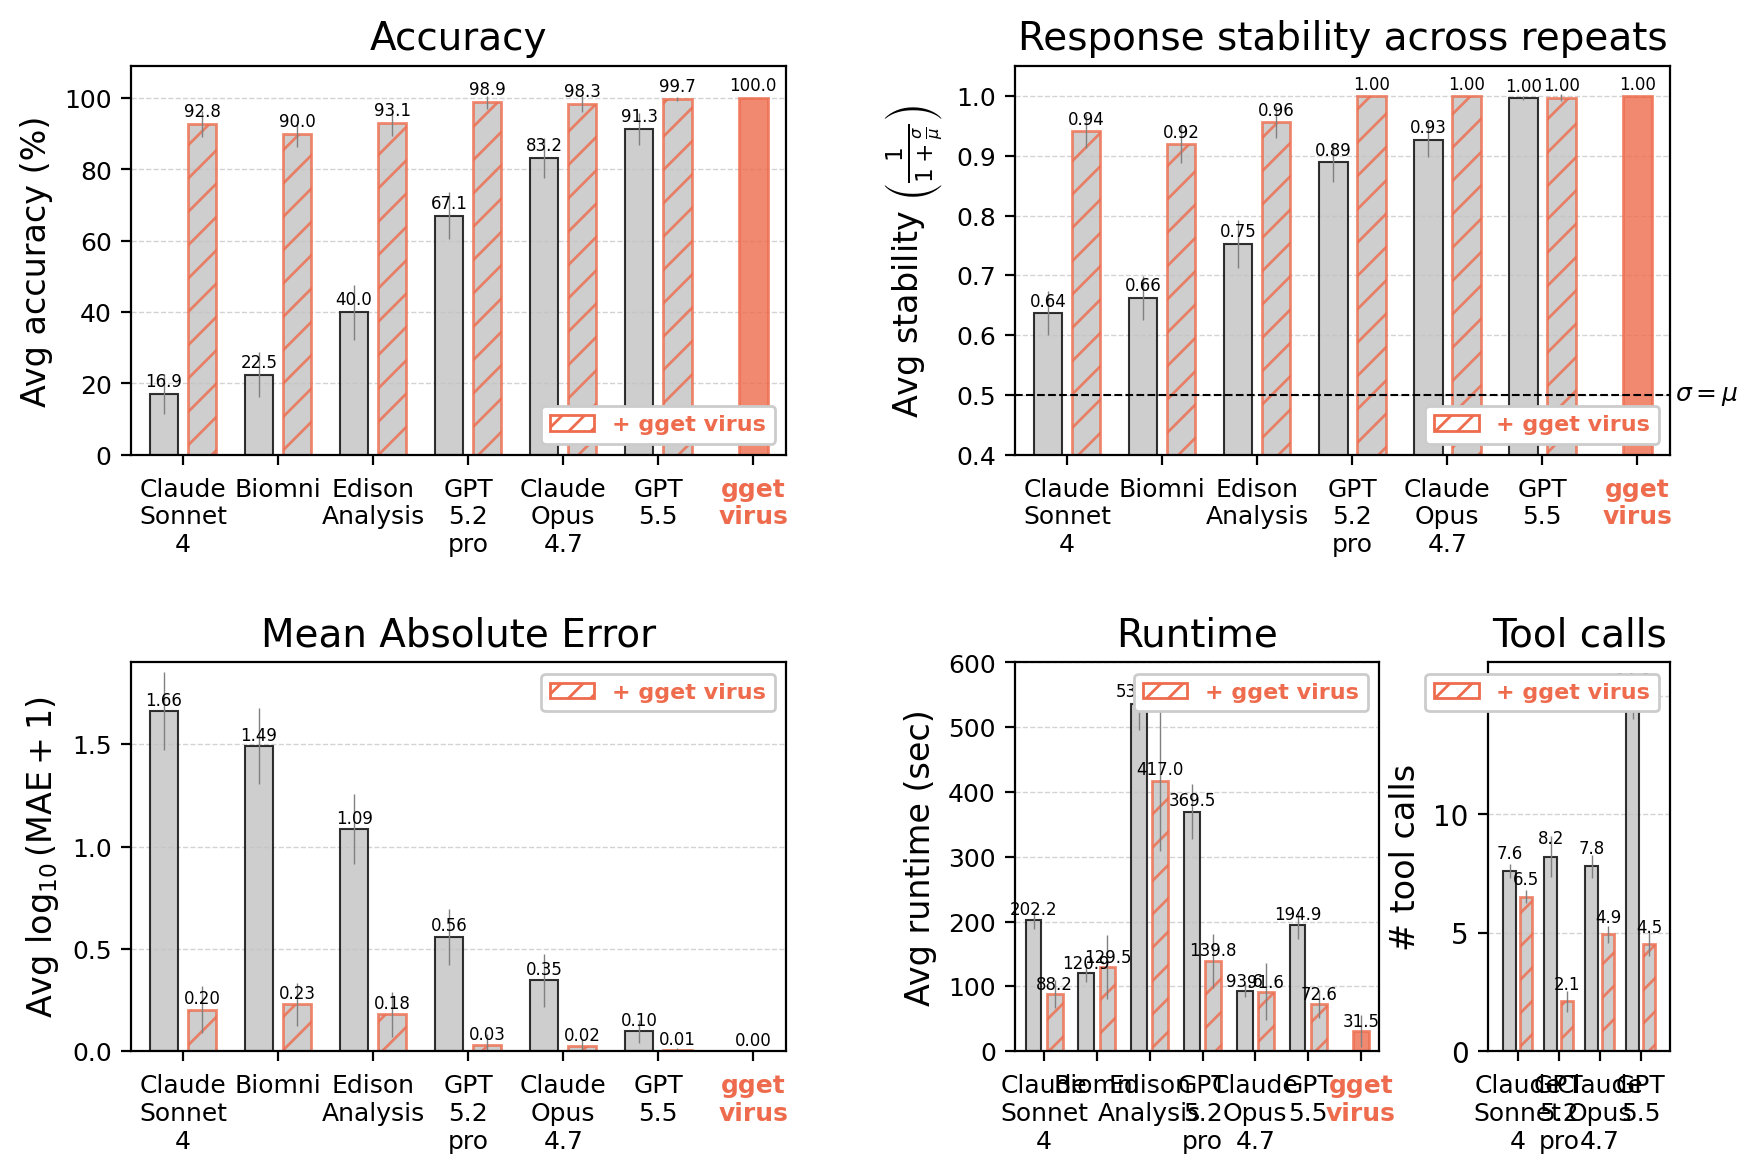

In [45]:
# --- Grouped TECHNOLOGIES for grouped bar plotting (two bars per group) ---

WITHIN_GROUP_BAR_GAP = 0.1  # Gap between two bars in a group

base_techs = [t for t in TECHNOLOGIES if "+ gget" not in t and t != "gget virus"]
GROUPED_TECHNOLOGIES = []
GROUPED_LABELS = []
for base in base_techs:
    gget_name = f"{base} + gget"
    if gget_name in SOURCES:
        GROUPED_TECHNOLOGIES.append((base, gget_name))
    else:
        GROUPED_TECHNOLOGIES.append((base,))
    # if " (" in base:
    #     agent, model = base.split(" (", 1)
    #     model = model.rstrip(")")
    #     GROUPED_LABELS.append(f"{agent}\n({model})")
    # else:
    GROUPED_LABELS.append(base.replace(" ", "\n"))
if "gget virus" in SOURCES:
    GROUPED_TECHNOLOGIES.append(("gget virus",))
    GROUPED_LABELS.append("gget\nvirus")

group_bar_width = 0.3
n_groups = len(GROUPED_TECHNOLOGIES)

# Print the total number of results for each category (each technology):
print("Total number of results per category (technology):")
for name in [t for group in GROUPED_TECHNOLOGIES for t in group]:
    # We'll assume metrics[name] is already populated as in the context
    if name in metrics:
        num_results = len(metrics[name]["accuracy"])
        print(f"  {name}: {num_results}")
    else:
        print(f"  {name}: MISSING IN METRICS")

# Compute x positions for each bar and group center, adding a small gap WITHIN groups
bar_x = []
group_centers = []
i_bar = 0
x_pos = 0.0
for i, group in enumerate(GROUPED_TECHNOLOGIES):
    if len(group) == 2:
        total_width = group_bar_width * 2 + WITHIN_GROUP_BAR_GAP
        bar1_x = x_pos - (group_bar_width/2 + WITHIN_GROUP_BAR_GAP/2)
        bar2_x = x_pos + (group_bar_width/2 + WITHIN_GROUP_BAR_GAP/2)
        bar_x += [bar1_x, bar2_x]
        group_centers.append(x_pos)
        x_pos += 1.0
        i_bar += 2
    else:
        # singleton
        bar_x.append(x_pos)
        group_centers.append(x_pos)
        x_pos += 1.0
        i_bar += 1

bar_positions = np.array(bar_x)
group_centers = np.array(group_centers)

from scipy import stats

def compute_ci95(values):
    """Half-width of the 95% confidence interval of the mean, ignoring NaNs."""
    valid = values[~np.isnan(values)]
    n = len(valid)
    if n > 1:
        sd = np.std(valid, ddof=1)
        sem = sd / np.sqrt(n)
        t_crit = stats.t.ppf(0.975, df=n - 1)
        return t_crit * sem
    return 0.0

def make_bars_grouped(ax, values, errors):
    """
    Draw two side-by-side bars for each paired group, singleton for single group.
    values, errors: flattened lists (len = total bars to draw)

    Error bars will only have vertical lines (no horizontal caps).
    """
    bar_colors = []
    hatches = []
    edgecols = []
    lwds = []
    val_idx = 0
    for group in GROUPED_TECHNOLOGIES:
        if len(group) == 2:
            color1 = COLORS[group[0]]
            color2 = COLORS[group[1]]
            bar_colors += [color1, color2]
            hatches += ['', HATCH.get(group[1], '')]
            edgecols += ["black", COLORS["gget virus"]]
            lwds += [0.75, 1]
            val_idx += 2
        else:
            # singleton
            color = COLORS[group[0]]
            bar_colors += [color]
            hatches += ['']
            edgecols += [COLORS["gget virus"] if "gget" in group[0] else "black"]
            lwds += [1 if "gget" in group[0] else 0.75]
            val_idx += 1

    # Workaround for TypeError: Ensure hatches, edgecolor, lw are passed as flat lists (not lists of lists)
    # Instead of passing as lists, let's make sure we cast all to the right type to comply with older matplotlib
    bars = []
    for i in range(len(bar_positions)):
        bars.append(ax.bar(
            [bar_positions[i]],
            [values[i]],
            yerr=[errors[i]],
            capsize=0,
            width=group_bar_width,
            color=bar_colors[i],
            edgecolor=edgecols[i],
            lw=lwds[i],
            alpha=0.8,
            ecolor="grey",
            error_kw=dict(lw=0.5, capthick=0),
            hatch=hatches[i]
        )[0])
    return bars

def set_grouped_xticklabels(ax, fontsize=FONTSIZE - 3):
    """Set multi-color and multi-line labels below each group of bars. DO NOT include '+ gget' labels."""
    ax.set_xticks(group_centers)
    # First set blank labels to ensure correct placement/margins
    ax.set_xticklabels(["" for _ in GROUPED_LABELS], fontsize=fontsize)
    # Now, manually color and build labels under each group
    line_height = fontsize * 1.2
    y_base = -8  # points below axes bottom
    common = dict(
        ha="center", va="top", fontsize=fontsize,
        annotation_clip=False,
    )

    # The model groups; for consistent label coloring, match GROUPED_LABELS to the TECHNOLOGIES
    # Provide a base mapping for label color
    color_map = []
    for group in GROUPED_TECHNOLOGIES:
        # Only FIRST label color of each group will be used
        base_color = XTICKLABEL_COLORS[group[0]]
        color_map.append((base_color,))

    for i, label in enumerate(GROUPED_LABELS):
        x = group_centers[i]
        colors = color_map[i]
        kw = common.copy()
        # Bold only the "gget virus" label (last group)
        if label.replace('\n',' ') == "gget virus" or i == len(GROUPED_LABELS) - 1:
            kw["fontweight"] = "bold"
        ax.annotate(label, xy=(x, 0), xycoords=("data", "axes fraction"),
                    xytext=(0, y_base), textcoords="offset points",
                    color=colors[0], **kw)

# ---- FLATTENED metric for grouped bars ----
def agg_grouped_flat(groups, field):
    "Flat value and std lists for the correct 2-bar layout per pair."
    values = []
    errors = []
    for group in groups:
        if len(group) == 2:
            vals1, vals2 = [], []
            if field == "mae":
                vals1 = np.log10(metrics[group[0]]["mae"] + 1.0)
                vals2 = np.log10(metrics[group[1]]["mae"] + 1.0)
            else:
                vals1 = np.array(metrics[group[0]][field])
                vals2 = np.array(metrics[group[1]][field])
            # accuracy: scale means * 100
            if field == "accuracy":
                values.extend([np.nanmean(vals1)*100, np.nanmean(vals2)*100])
                errors.extend([compute_ci95(vals1)*100, compute_ci95(vals2)*100])
            else:
                values.extend([np.nanmean(vals1), np.nanmean(vals2)])
                errors.extend([compute_ci95(vals1), compute_ci95(vals2)])
        else:
            # singleton
            if field == "mae":
                vals = np.log10(metrics[group[0]]["mae"] + 1.0)
            else:
                vals = np.array(metrics[group[0]][field])
            if field == "accuracy":
                values.append(np.nanmean(vals)*100)
                errors.append(compute_ci95(vals)*100)
            else:
                values.append(np.nanmean(vals))
                errors.append(compute_ci95(vals))
    return values, errors

import matplotlib.patches as mpatches

from matplotlib import gridspec as gs_mod

fig = plt.figure(figsize=(9, 6))
outer = gs_mod.GridSpec(2, 2, figure=fig, width_ratios=[1, 1], height_ratios=[1, 1])
axes = np.empty((2, 2), dtype=object)
axes[0, 0] = fig.add_subplot(outer[0, 0])
axes[0, 1] = fig.add_subplot(outer[0, 1])
axes[1, 0] = fig.add_subplot(outer[1, 0])
# Split bottom-right into 2/3 runtime + 1/3 tool calls
inner_br = gs_mod.GridSpecFromSubplotSpec(1, 2, subplot_spec=outer[1, 1], width_ratios=[2, 1], wspace=0.4)
axes[1, 1] = fig.add_subplot(inner_br[0, 0])
ax_tc = fig.add_subplot(inner_br[0, 1])

def connect_group_means(ax, values):
    """
    For each two-bar group (paired bars), draw a black line connecting the means.
    """
    group_i = 0
    val_idx = 0
    for group in GROUPED_TECHNOLOGIES:
        if len(group) == 2:
            x1 = bar_positions[val_idx]
            x2 = bar_positions[val_idx + 1]
            y1 = values[val_idx]
            y2 = values[val_idx + 1]
            ax.plot([x1, x2], [y1, y2], color="black", linewidth=0.5, zorder=10)
            val_idx += 2
        else:
            val_idx += 1
        group_i += 1

# Fontsize reduction for bar labels
BAR_LABEL_FONTSIZE = FONTSIZE - 6
Y_LABEL_FONTSIZE = FONTSIZE - 3

# Top-left: Accuracy
ax = axes[0, 0]
ax.set_axisbelow(True)
ax.yaxis.grid(True, color="lightgrey", linestyle="--", linewidth=0.5)
acc_means, acc_sd = agg_grouped_flat(GROUPED_TECHNOLOGIES, "accuracy")
bars = make_bars_grouped(ax, acc_means, acc_sd)
for i, bar in enumerate(bars):
    val = acc_means[i]
    ax.text(bar.get_x() + bar.get_width()/2, val + 1, f"{val:.1f}", ha="center", va="bottom", fontsize=BAR_LABEL_FONTSIZE)
# connect_group_means(ax, acc_means)
set_grouped_xticklabels(ax)
ax.set_ylim(0, 109)
ax.margins(x=0.03)
ax.set_ylabel("Avg accuracy (%)", fontsize=FONTSIZE)
ax.set_title("Accuracy", fontsize=FONTSIZE + 2)
ax.tick_params(axis="y", labelsize=Y_LABEL_FONTSIZE)

# Top-right: Stability
ax = axes[0, 1]
ax.set_axisbelow(True)
ax.yaxis.grid(True, color="lightgrey", linestyle="--", linewidth=0.5)
stab_means, stab_sd = agg_grouped_flat(GROUPED_TECHNOLOGIES, "stability")
bars = make_bars_grouped(ax, stab_means, stab_sd)
for i, bar in enumerate(bars):
    val = stab_means[i]
    ax.text(bar.get_x() + bar.get_width()/2, val + 0.005, f"{val:.2f}", ha="center", va="bottom", fontsize=BAR_LABEL_FONTSIZE)
# connect_group_means(ax, stab_means)
set_grouped_xticklabels(ax)
ax.set_ylim(0.4, 1.05)
ax.margins(x=0.03)
ax.axhline(0.5, linestyle="--", linewidth=0.75, c="black")
ax.text(6.4, 0.5, r"$\sigma = \mu$", fontsize=Y_LABEL_FONTSIZE, va="center", ha="left", c="black")
ax.set_ylabel(r"Avg stability $\left(\frac{1}{1 + \frac{\sigma}{\mu}}\right)$", fontsize=FONTSIZE)
ax.set_title("Response stability across repeats", fontsize=FONTSIZE + 2)
ax.tick_params(axis="y", labelsize=Y_LABEL_FONTSIZE)

# Bottom-left: MAE
ax = axes[1, 0]
ax.set_axisbelow(True)
ax.yaxis.grid(True, color="lightgrey", linestyle="--", linewidth=0.5)
mae_means, mae_sd = agg_grouped_flat(GROUPED_TECHNOLOGIES, "mae")
bars = make_bars_grouped(ax, mae_means, mae_sd)
for i, bar in enumerate(bars):
    val = mae_means[i]
    ax.text(bar.get_x() + bar.get_width()/2, val + 0.01, f"{val:.2f}", ha="center", va="bottom", fontsize=BAR_LABEL_FONTSIZE)
# connect_group_means(ax, mae_means)
set_grouped_xticklabels(ax)
ax.set_ylim(0, 1.9)
ax.margins(x=0.03)
ax.set_ylabel(r"Avg $\log_{10}(\mathrm{MAE} + 1)$", fontsize=FONTSIZE)
ax.set_title("Mean Absolute Error", fontsize=FONTSIZE + 2)
ax.tick_params(axis="y", labelsize=Y_LABEL_FONTSIZE)

# Bottom-right: Duration
ax = axes[1, 1]
ax.set_axisbelow(True)
ax.yaxis.grid(True, color="lightgrey", linestyle="--", linewidth=0.5)
dur_means, dur_sd = agg_grouped_flat(GROUPED_TECHNOLOGIES, "duration")
bars = make_bars_grouped(ax, dur_means, dur_sd)
for i, bar in enumerate(bars):
    val = dur_means[i]
    ax.text(bar.get_x() + bar.get_width()/2, val + val * 0.01, f"{val:.1f}", ha="center", va="bottom", fontsize=BAR_LABEL_FONTSIZE)
# connect_group_means(ax, dur_means)
set_grouped_xticklabels(ax)
ax.set_ylim(0,600)
ax.margins(x=0.03)
ax.set_ylabel("Avg runtime (sec)", fontsize=FONTSIZE)
ax.set_title("Runtime", fontsize=FONTSIZE + 2)
ax.tick_params(axis="y", labelsize=Y_LABEL_FONTSIZE)

# Bottom-right-right: Tool calls (only Claude and GPT)
ax = ax_tc
ax.set_axisbelow(True)
ax.yaxis.grid(True, color="lightgrey", linestyle="--", linewidth=0.5)
# Build tool call bars using same grouped layout but only for models with data
tc_values = []
tc_errors = []
tc_bar_positions_local = []
tc_bar_colors = []
tc_hatches_local = []
tc_edgecols = []
tc_lwds = []
tc_group_centers_local = []
tc_group_labels_local = []
tc_idx = 0
for gi, group in enumerate(GROUPED_TECHNOLOGIES):
    has_data = any(name in tool_call_data for name in group)
    if not has_data:
        continue
    if len(group) == 2:
        for j, name in enumerate(group):
            vals = tool_call_data.get(name, np.array([]))
            vals = vals[~np.isnan(vals)] if len(vals) > 0 else vals
            tc_values.append(np.nanmean(vals) if len(vals) > 0 else 0)
            tc_errors.append(compute_ci95(vals) if len(vals) > 1 else 0)
            offset = -group_bar_width/2 - WITHIN_GROUP_BAR_GAP/2 if j == 0 else group_bar_width/2 + WITHIN_GROUP_BAR_GAP/2
            tc_bar_positions_local.append(tc_idx + offset)
            tc_bar_colors.append(COLORS[name])
            tc_edgecols.append("black" if j == 0 else COLORS["gget virus"])
            tc_lwds.append(0.75 if j == 0 else 1)
            tc_hatches_local.append("" if j == 0 else HATCH.get(name, ""))
        tc_group_centers_local.append(tc_idx)
        tc_group_labels_local.append((GROUPED_LABELS[gi], group))
        tc_idx += 1
    else:
        name = group[0]
        if name in tool_call_data:
            vals = tool_call_data[name]
            vals = vals[~np.isnan(vals)] if len(vals) > 0 else vals
            tc_values.append(np.nanmean(vals) if len(vals) > 0 else 0)
            tc_errors.append(compute_ci95(vals) if len(vals) > 1 else 0)
            tc_bar_positions_local.append(tc_idx)
            tc_bar_colors.append(COLORS[name])
            tc_edgecols.append("black")
            tc_lwds.append(0.75)
            tc_hatches_local.append("")
            tc_group_centers_local.append(tc_idx)
            tc_group_labels_local.append((GROUPED_LABELS[gi], group))
            tc_idx += 1

for i in range(len(tc_bar_positions_local)):
    ax.bar(
        [tc_bar_positions_local[i]], [tc_values[i]], yerr=[tc_errors[i]],
        capsize=0, width=group_bar_width, color=tc_bar_colors[i],
        edgecolor=tc_edgecols[i], lw=tc_lwds[i], alpha=0.8,
        ecolor="grey", error_kw=dict(lw=0.5, capthick=0),
        hatch=tc_hatches_local[i]
    )
    ax.text(tc_bar_positions_local[i], tc_values[i] + tc_values[i] * 0.01 + 0.3,
            f"{tc_values[i]:.1f}", ha="center", va="bottom", fontsize=BAR_LABEL_FONTSIZE)

ax.set_xticks(tc_group_centers_local)
ax.set_xticklabels([""] * len(tc_group_centers_local))
for (label, group), x in zip(tc_group_labels_local, tc_group_centers_local):
    color = XTICKLABEL_COLORS[group[0]]
    kw = dict(ha="center", va="top", fontsize=FONTSIZE - 3, annotation_clip=False)
    ax.annotate(label, xy=(x, 0), xycoords=("data", "axes fraction"),
                xytext=(0, -8), textcoords="offset points", color=color, **kw)
ax.margins(x=0.1)
ax.set_ylabel("# tool calls", fontsize=FONTSIZE)
ax.set_title("Tool calls", fontsize=FONTSIZE + 2)
ax.tick_params(axis="y", labelsize=FONTSIZE - 2)
ax.set_ylim(0)

# ---- Add legend: colored/hatched boxes to explain both main models and "+ gget virus" ----
from matplotlib.patches import Patch

legend_handles = []

# Handle for "+ gget virus" with denser hatch
gget_patch = Patch(
    facecolor="white",
    edgecolor=COLORS["gget virus"],
    hatch="///",
    label="+ gget virus",
    linewidth=1,
)
legend_handles.append(gget_patch)

# # Place the legend in the upper left of the whole figure, moving it a bit higher
# leg = fig.legend(
#     handles=legend_handles,
#     loc="upper left",
#     bbox_to_anchor=(0.01, 1.02),  # was 0.995, now slightly higher
#     borderaxespad=0.5,
#     fontsize=FONTSIZE-2,
#     frameon=True
# )

for idx, ax in enumerate(list(axes.flat) + [ax_tc]):
    # For top two plots, place the legend in the lower right corner; else (bottom), leave in upper right
    if idx < 2:
        legend_loc = "lower right"
    else:
        legend_loc = "upper right"
    leg = ax.legend(
        handles=legend_handles,
        loc=legend_loc,
        borderaxespad=0.5,
        fontsize=FONTSIZE-4,
        frameon=True
    )
    leg.set_alpha(1)  # Make legend background fully opaque
    leg.get_frame().set_alpha(1)

    for text in leg.get_texts():
        if text.get_text() == "+ gget virus":
            text.set_color(COLORS["gget virus"])
            text.set_fontweight("bold")
     

# Slightly increase the space between subplots by increasing h_pad and w_pad
fig.tight_layout(h_pad=1.9, w_pad=1.8)
fig.subplots_adjust(wspace=0.35)
fig.savefig("../figures/averages.png", dpi=300, bbox_inches="tight")


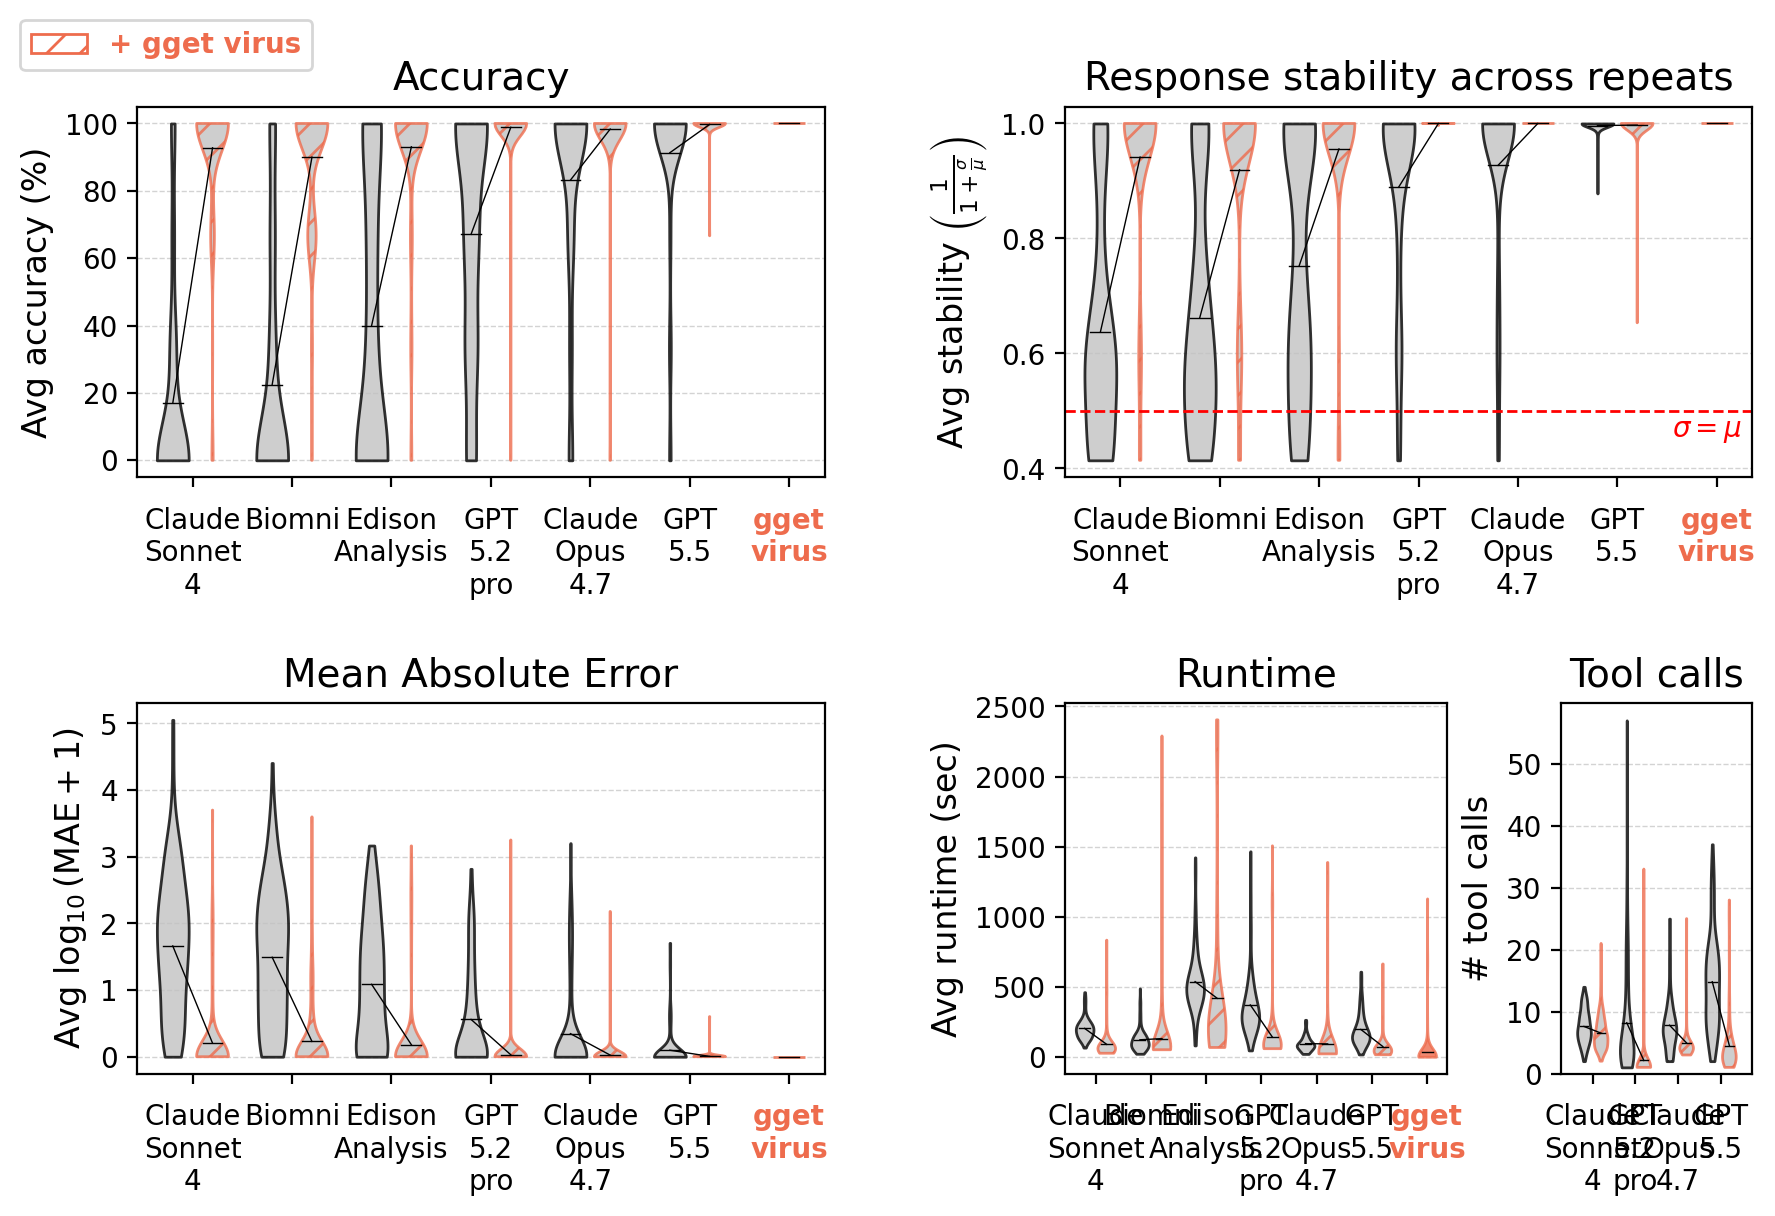

In [41]:
bon_groups = len(GROUPED_TECHNOLOGIES)
violin_spacing = 0.4
group_centers = np.arange(n_groups)

def collect_grouped_data(groups, field):
    """Flat list of arrays per violin for correct 2-violin layout.
    NaN values are filtered out so matplotlib's violinplot KDE can handle the data.
    """
    list_of_data = []
    for group in groups:
        if len(group) == 2:
            # Two models in group
            if field == "mae":
                vals1 = np.log10(metrics[group[0]]["mae"] + 1.0)
                vals2 = np.log10(metrics[group[1]]["mae"] + 1.0)
            else:
                vals1 = np.array(metrics[group[0]][field])
                vals2 = np.array(metrics[group[1]][field])
            if field == "accuracy":
                vals1 = vals1 * 100
                vals2 = vals2 * 100
            # Filter NaN values (from cases where all runs errored)
            vals1 = vals1[~np.isnan(vals1)]
            vals2 = vals2[~np.isnan(vals2)]
            list_of_data += [vals1, vals2]
        else:
            # Singleton
            if field == "mae":
                vals = np.log10(metrics[group[0]]["mae"] + 1.0)
            else:
                vals = np.array(metrics[group[0]][field])
            if field == "accuracy":
                vals = vals * 100
            # Filter NaN values
            vals = vals[~np.isnan(vals)]
            list_of_data.append(vals)
    return list_of_data

def grouped_violin_positions(groups, spacing=violin_spacing):
    """Calculate x positions for each violin for grouped layout."""
    x_positions = []
    for idx, group in enumerate(groups):
        if len(group) == 2:
            x_positions += [idx - spacing/2, idx + spacing/2]
        else:
            x_positions.append(idx)
    return np.array(x_positions)

violin_positions = grouped_violin_positions(GROUPED_TECHNOLOGIES)

def set_grouped_xticklabels(ax, fontsize=FONTSIZE - 2):
    """
    Set multi-color and multi-line labels below each group of violins.
    DO NOT include '+ gget' labels.
    Also removes the default numbered xticklabels (0-4).
    """
    ax.set_xticks(group_centers)
    # Remove default numbered xticklabels
    ax.set_xticklabels([''] * len(group_centers))
    for label, group, x in zip(GROUPED_LABELS, GROUPED_TECHNOLOGIES, group_centers):
        color = XTICKLABEL_COLORS[group[0]]
        label_kwargs = {
            'color': color,
            'ha': "center",
            'va': "top",
            'fontsize': fontsize,
            'transform': ax.get_xaxis_transform(),
            'clip_on': False,
        }
        # Bold the xticklabel if it's for "gget virus"
        if isinstance(label, str) and ("gget" in label and "gget virus" in label):
            label_kwargs['fontweight'] = 'bold'
        elif isinstance(label, str) and ("gget virus" == label):
            label_kwargs['fontweight'] = 'bold'
        elif len(group) == 1 and "gget" in group[0]:
            label_kwargs['fontweight'] = 'bold'
        ax.text(x, -0.08, label, **label_kwargs)

from matplotlib import gridspec as gs_mod

fig = plt.figure(figsize=(9, 6))
outer = gs_mod.GridSpec(2, 2, figure=fig, width_ratios=[1, 1], height_ratios=[1, 1])
axes = np.empty((2, 2), dtype=object)
axes[0, 0] = fig.add_subplot(outer[0, 0])
axes[0, 1] = fig.add_subplot(outer[0, 1])
axes[1, 0] = fig.add_subplot(outer[1, 0])
# Split bottom-right into 2/3 runtime + 1/3 tool calls
inner_br = gs_mod.GridSpecFromSubplotSpec(1, 2, subplot_spec=outer[1, 1], width_ratios=[2, 1], wspace=0.4)
axes[1, 1] = fig.add_subplot(inner_br[0, 0])
ax_tc = fig.add_subplot(inner_br[0, 1])

def plot_grouped_violins(ax, groups, field, violin_positions, facecolors, edgecolors, alphas, means_as_text=True, hatch_styles=None):
    """
    Plot grouped violins and return the mean values per violin for annotation.
    Means are plotted and annotated in black. Also returns x/y of means for connecting.

    Bar text labels will be positioned above the violin body (above the maximum value in the group).
    """
    data = collect_grouped_data(groups, field)

    # Skip datasets with fewer than 2 points (KDE needs at least 2)
    valid_idx = [i for i, d in enumerate(data) if len(d) >= 2]
    if valid_idx:
        parts = ax.violinplot(
            [data[i] for i in valid_idx],
            positions=[violin_positions[i] for i in valid_idx],
            widths=violin_spacing * 0.8,
            showmeans=False,
            showmedians=False,
            showextrema=False,
        )
        # Color/hatch each violin body — map back to original indices
        for j, body in enumerate(parts['bodies']):
            i = valid_idx[j]
            body.set_facecolor(facecolors[i])
            body.set_edgecolor(edgecolors[i])
            body.set_alpha(alphas[i])
            body.set_linewidth(1)
            if hatch_styles and hatch_styles[i]:
                body.set_hatch(hatch_styles[i])

    means = []
    for i, d in enumerate(data):
        mv = np.mean(d) if len(d) > 0 else np.nan
        means.append(mv)
        # Draw the mean as a horizontal black line
        if not np.isnan(mv):
            ax.plot([violin_positions[i] - violin_spacing * 0.25, violin_positions[i] + violin_spacing * 0.25],
                    [mv, mv], color="black", lw=0.5, zorder=3)
    # Return means for connection
    return means

def connect_group_means(ax, groups, means, violin_positions):
    """
    For each group with 2 elements, connect the mean points with a black line.
    """
    idx = 0
    for group in groups:
        if len(group) == 2:
            x0, x1 = violin_positions[idx], violin_positions[idx+1]
            y0, y1 = means[idx], means[idx+1]
            # Only draw line if both means are finite
            if np.isfinite(y0) and np.isfinite(y1):
                ax.plot([x0, x1], [y0, y1], color="black", linewidth=0.5, zorder=4)
            idx += 2
        else:
            idx += 1


# Helper for violin styles
def violin_color_lists(groups):
    color_list = []
    edge_list = []
    alpha_list = []
    hatch_list = []
    for group in groups:
        if len(group) == 2:
            color_list += [COLORS[group[0]], COLORS[group[1]]]
            edge_list += ["black", COLORS["gget virus"]]
            alpha_list += [0.8, 0.8]
            hatch_list += ['', HATCH.get(group[1], "")]
        else:
            color_list.append(COLORS[group[0]])
            edge_list.append(COLORS["gget virus"] if "gget" in group[0] else "black")
            alpha_list.append(0.8)
            hatch_list.append('')
    return color_list, edge_list, alpha_list, hatch_list

# Top-left: Accuracy
ax = axes[0, 0]
ax.set_axisbelow(True)
ax.yaxis.grid(True, color="lightgrey", linestyle="--", linewidth=0.5)
facecolors, edgecolors, alphas, hatch_styles = violin_color_lists(GROUPED_TECHNOLOGIES)
means = plot_grouped_violins(ax, GROUPED_TECHNOLOGIES, "accuracy", violin_positions, facecolors, edgecolors, alphas, True, hatch_styles)
connect_group_means(ax, GROUPED_TECHNOLOGIES, means, violin_positions)
set_grouped_xticklabels(ax, fontsize=FONTSIZE - 2)
# ax.set_ylim(0, 110)
ax.margins(x=0.03)
ax.set_ylabel("Avg accuracy (%)", fontsize=FONTSIZE)
ax.set_title("Accuracy", fontsize=FONTSIZE + 2)
ax.tick_params(axis="y", labelsize=FONTSIZE - 2)
ax.tick_params(axis="x", labelsize=FONTSIZE - 2)

# Top-right: Stability
ax = axes[0, 1]
ax.set_axisbelow(True)
ax.yaxis.grid(True, color="lightgrey", linestyle="--", linewidth=0.5)
facecolors, edgecolors, alphas, hatch_styles = violin_color_lists(GROUPED_TECHNOLOGIES)
means = plot_grouped_violins(ax, GROUPED_TECHNOLOGIES, "stability", violin_positions, facecolors, edgecolors, alphas, True, hatch_styles)
connect_group_means(ax, GROUPED_TECHNOLOGIES, means, violin_positions)
set_grouped_xticklabels(ax, fontsize=FONTSIZE - 2)
# ax.set_ylim(0.4, 1.07)
ax.margins(x=0.03)
ax.axhline(0.5, linestyle="--", linewidth=1, c="red")
ax.text(violin_positions[-1]-0.1, 0.49, r"$\sigma = \mu$", fontsize=FONTSIZE - 2, va="top", ha="center", c="red")
ax.set_ylabel(r"Avg stability $\left(\frac{1}{1 + \frac{\sigma}{\mu}}\right)$", fontsize=FONTSIZE)
ax.set_title("Response stability across repeats", fontsize=FONTSIZE + 2)
ax.tick_params(axis="y", labelsize=FONTSIZE - 2)
ax.tick_params(axis="x", labelsize=FONTSIZE - 2)

# Bottom-left: MAE
ax = axes[1, 0]
ax.set_axisbelow(True)
ax.yaxis.grid(True, color="lightgrey", linestyle="--", linewidth=0.5)
facecolors, edgecolors, alphas, hatch_styles = violin_color_lists(GROUPED_TECHNOLOGIES)
means = plot_grouped_violins(ax, GROUPED_TECHNOLOGIES, "mae", violin_positions, facecolors, edgecolors, alphas, True, hatch_styles)
connect_group_means(ax, GROUPED_TECHNOLOGIES, means, violin_positions)
set_grouped_xticklabels(ax, fontsize=FONTSIZE - 2)
# ax.set_ylim(0, 2.1)
ax.margins(x=0.03)
ax.set_ylabel(r"Avg $\log_{10}(\mathrm{MAE} + 1)$", fontsize=FONTSIZE)
ax.set_title("Mean Absolute Error", fontsize=FONTSIZE + 2)
ax.tick_params(axis="y", labelsize=FONTSIZE - 2)
ax.tick_params(axis="x", labelsize=FONTSIZE - 2)

# Bottom-right: Duration
ax = axes[1, 1]
ax.set_axisbelow(True)
ax.yaxis.grid(True, color="lightgrey", linestyle="--", linewidth=0.5)
facecolors, edgecolors, alphas, hatch_styles = violin_color_lists(GROUPED_TECHNOLOGIES)
means = plot_grouped_violins(ax, GROUPED_TECHNOLOGIES, "duration", violin_positions, facecolors, edgecolors, alphas, True, hatch_styles)
connect_group_means(ax, GROUPED_TECHNOLOGIES, means, violin_positions)
set_grouped_xticklabels(ax, fontsize=FONTSIZE - 2)
# ax.set_ylim(0, 610)
ax.margins(x=0.03)
ax.set_ylabel("Avg runtime (sec)", fontsize=FONTSIZE)
ax.set_title("Runtime", fontsize=FONTSIZE + 2)
ax.tick_params(axis="y", labelsize=FONTSIZE - 2)
ax.tick_params(axis="x", labelsize=FONTSIZE - 2)

# Bottom-right-right: Tool calls violin (only Claude and GPT)
ax = ax_tc
ax.set_axisbelow(True)
ax.yaxis.grid(True, color="lightgrey", linestyle="--", linewidth=0.5)

# Build tool call violin data using same grouped layout but only for models with data
tc_plot_data = []
tc_violin_pos = []
tc_facecolors_local = []
tc_edgecolors_local = []
tc_alphas_local = []
tc_hatches_local = []
tc_group_centers_local = []
tc_group_labels_local = []
tc_idx = 0
for gi, group in enumerate(GROUPED_TECHNOLOGIES):
    has_data = any(name in tool_call_data for name in group)
    if not has_data:
        continue
    if len(group) == 2:
        for j, name in enumerate(group):
            vals = tool_call_data.get(name, np.array([]))
            vals = vals[~np.isnan(vals)] if len(vals) > 0 else vals
            tc_plot_data.append(vals)
            offset = -violin_spacing/2 if j == 0 else violin_spacing/2
            tc_violin_pos.append(tc_idx + offset)
            tc_facecolors_local.append(COLORS[name])
            tc_edgecolors_local.append("black" if j == 0 else COLORS["gget virus"])
            tc_alphas_local.append(0.8)
            tc_hatches_local.append("" if j == 0 else HATCH.get(name, ""))
        tc_group_centers_local.append(tc_idx)
        tc_group_labels_local.append((GROUPED_LABELS[gi], group))
        tc_idx += 1
    else:
        name = group[0]
        if name in tool_call_data:
            vals = tool_call_data[name]
            vals = vals[~np.isnan(vals)] if len(vals) > 0 else vals
            tc_plot_data.append(vals)
            tc_violin_pos.append(tc_idx)
            tc_facecolors_local.append(COLORS[name])
            tc_edgecolors_local.append("black")
            tc_alphas_local.append(0.8)
            tc_hatches_local.append("")
            tc_group_centers_local.append(tc_idx)
            tc_group_labels_local.append((GROUPED_LABELS[gi], group))
            tc_idx += 1

tc_violin_pos = np.array(tc_violin_pos)
tc_valid_idx = [i for i, d in enumerate(tc_plot_data) if len(d) >= 2]
if tc_valid_idx:
    tc_parts = ax.violinplot(
        [tc_plot_data[i] for i in tc_valid_idx],
        positions=[tc_violin_pos[i] for i in tc_valid_idx],
        widths=violin_spacing * 0.8,
        showmeans=False, showmedians=False, showextrema=False,
    )
    for j, body in enumerate(tc_parts["bodies"]):
        i = tc_valid_idx[j]
        body.set_facecolor(tc_facecolors_local[i])
        body.set_edgecolor(tc_edgecolors_local[i])
        body.set_alpha(tc_alphas_local[i])
        body.set_linewidth(1)
        if tc_hatches_local[i]:
            body.set_hatch(tc_hatches_local[i])

tc_means = []
for i, d in enumerate(tc_plot_data):
    mv = np.mean(d) if len(d) > 0 else np.nan
    tc_means.append(mv)
    if not np.isnan(mv):
        ax.plot([tc_violin_pos[i] - violin_spacing * 0.25, tc_violin_pos[i] + violin_spacing * 0.25],
                [mv, mv], color="black", lw=0.5, zorder=3)

# Connect paired means
_tc_vi = 0
for gi, group in enumerate(GROUPED_TECHNOLOGIES):
    has_data = any(name in tool_call_data for name in group)
    if not has_data:
        continue
    if len(group) == 2:
        x0, x1 = tc_violin_pos[_tc_vi], tc_violin_pos[_tc_vi + 1]
        y0, y1 = tc_means[_tc_vi], tc_means[_tc_vi + 1]
        if np.isfinite(y0) and np.isfinite(y1):
            ax.plot([x0, x1], [y0, y1], color="black", linewidth=0.5, zorder=4)
        _tc_vi += 2
    else:
        _tc_vi += 1

ax.set_xticks(tc_group_centers_local)
ax.set_xticklabels([""] * len(tc_group_centers_local))
for (label, group), x in zip(tc_group_labels_local, tc_group_centers_local):
    ax.text(x, -0.08, label, color=XTICKLABEL_COLORS[group[0]],
            ha="center", va="top", fontsize=FONTSIZE - 2,
            transform=ax.get_xaxis_transform(), clip_on=False)
ax.margins(x=0.1)
ax.set_ylabel("# tool calls", fontsize=FONTSIZE)
ax.set_title("Tool calls", fontsize=FONTSIZE + 2)
ax.tick_params(axis="y", labelsize=FONTSIZE - 2)
ax.tick_params(axis="x", labelsize=FONTSIZE - 2)
ax.set_ylim(0)

legend_handles = []

# Handle for "+ gget virus" with denser hatch
gget_patch = Patch(
    facecolor="white",
    edgecolor=COLORS["gget virus"],
    hatch="//",
    label="+ gget virus",
    linewidth=1,
)
legend_handles.append(gget_patch)

# Place the legend in the upper left of the whole figure, moving it a bit higher
leg = fig.legend(
    handles=legend_handles,
    loc="upper left",
    bbox_to_anchor=(0.01, 1.02),
    borderaxespad=0.5,
    fontsize=FONTSIZE-2,
    frameon=True
)
# Set the legend label color for "+ gget virus" entry AND bold it
for text in leg.get_texts():
    if text.get_text() == "+ gget virus":
        text.set_color(COLORS["gget virus"])
        text.set_fontweight("bold")
# leg.get_frame().set_linewidth(1)
# leg.get_frame().set_alpha(0.8)

fig.tight_layout(h_pad=1.9, w_pad=1.8)
fig.subplots_adjust(wspace=0.35)
fig.savefig("../figures/averages_violin.png", dpi=300, bbox_inches="tight")


# Plot # tool calls

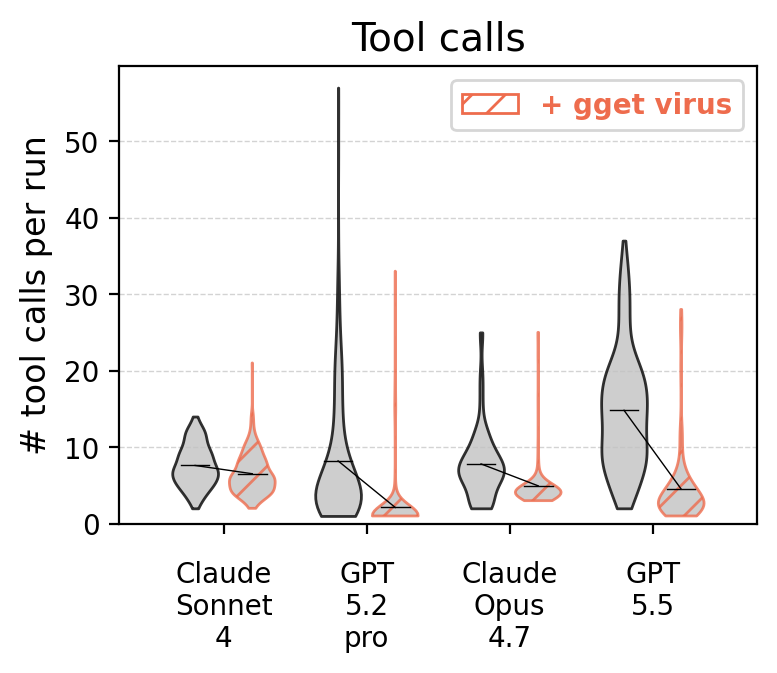

In [28]:
# Tool call data already loaded in load-tool-calls cell above

# Grouped layout: pair each base model with its + gget variant
tc_base = [t for t in TOOL_CALL_SOURCES if "+ gget" not in t]
TC_GROUPS = []
TC_LABELS = []
for base in tc_base:
    gget_name = f"{base} + gget"
    if gget_name in TOOL_CALL_SOURCES:
        TC_GROUPS.append((base, gget_name))
    else:
        continue
    if " (" in base:
        agent, model = base.split(" (", 1)
        model = model.rstrip(")")
        TC_LABELS.append(f"{agent}\n({model})")
    else:
        TC_LABELS.append(base.replace(" ", "\n"))
n_tc_groups = len(TC_GROUPS)
tc_spacing = 0.4
tc_group_centers = np.arange(n_tc_groups)

tc_violin_positions = []
for idx, group in enumerate(TC_GROUPS):
    tc_violin_positions += [idx - tc_spacing / 2, idx + tc_spacing / 2]
tc_violin_positions = np.array(tc_violin_positions)

# Build style lists
tc_facecolors = []
tc_edgecolors = []
tc_alphas = []
tc_hatches = []
for group in TC_GROUPS:
    tc_facecolors += [COLORS[group[0]], COLORS[group[1]]]
    tc_edgecolors += ["black", COLORS["gget virus"]]
    tc_alphas += [0.8, 0.8]
    tc_hatches += ["", HATCH.get(group[1], "")]

# Collect data arrays (NaN-filtered)
tc_plot_data = []
for group in TC_GROUPS:
    for name in group:
        vals = tool_call_data.get(name, np.array([]))
        vals = vals[~np.isnan(vals)]
        tc_plot_data.append(vals)

fig, ax = plt.subplots(figsize=(4, 3.5))
ax.set_axisbelow(True)
ax.yaxis.grid(True, color="lightgrey", linestyle="--", linewidth=0.5)

# Plot violins
valid_idx = [i for i, d in enumerate(tc_plot_data) if len(d) >= 2]
if valid_idx:
    parts = ax.violinplot(
        [tc_plot_data[i] for i in valid_idx],
        positions=[tc_violin_positions[i] for i in valid_idx],
        widths=tc_spacing * 0.8,
        showmeans=False,
        showmedians=False,
        showextrema=False,
    )
    for j, body in enumerate(parts["bodies"]):
        i = valid_idx[j]
        body.set_facecolor(tc_facecolors[i])
        body.set_edgecolor(tc_edgecolors[i])
        body.set_alpha(tc_alphas[i])
        body.set_linewidth(1)
        if tc_hatches[i]:
            body.set_hatch(tc_hatches[i])

# Draw mean lines and connect group means
means = []
for i, d in enumerate(tc_plot_data):
    mv = np.mean(d) if len(d) > 0 else np.nan
    means.append(mv)
    if not np.isnan(mv):
        ax.plot(
            [tc_violin_positions[i] - tc_spacing * 0.25, tc_violin_positions[i] + tc_spacing * 0.25],
            [mv, mv], color="black", lw=0.5, zorder=3,
        )

# Connect paired means
idx = 0
for group in TC_GROUPS:
    x0, x1 = tc_violin_positions[idx], tc_violin_positions[idx + 1]
    y0, y1 = means[idx], means[idx + 1]
    if np.isfinite(y0) and np.isfinite(y1):
        ax.plot([x0, x1], [y0, y1], color="black", linewidth=0.5, zorder=4)
    idx += 2

# X-axis labels
ax.set_xticks(tc_group_centers)
ax.set_xticklabels([""] * n_tc_groups)
for label, group, x in zip(TC_LABELS, TC_GROUPS, tc_group_centers):
    ax.text(
        x, -0.08, label,
        color=XTICKLABEL_COLORS[group[0]],
        ha="center", va="top",
        fontsize=FONTSIZE - 2,
        transform=ax.get_xaxis_transform(),
        clip_on=False,
    )

ax.margins(x=0.1)
ax.set_ylabel("# tool calls per run", fontsize=FONTSIZE)
ax.set_title("Tool calls", fontsize=FONTSIZE + 2)
ax.tick_params(axis="y", labelsize=FONTSIZE - 2)
ax.tick_params(axis="x", labelsize=FONTSIZE - 2)
ax.set_ylim(0)

# Legend
from matplotlib.patches import Patch
leg = ax.legend(
    handles=[Patch(facecolor="white", edgecolor=COLORS["gget virus"], hatch="//", label="+ gget virus", linewidth=1)],
    loc="upper right",
    fontsize=FONTSIZE - 2,
    frameon=True,
)
for text in leg.get_texts():
    text.set_color(COLORS["gget virus"])
    text.set_fontweight("bold")

fig.tight_layout()
fig.savefig("../figures/tool_calls.png", dpi=300, bbox_inches="tight")


# Show cost or tokens ?

# Unique pathogens

In [29]:
# Unique pathogens in config order
all_pathogens = list(dict.fromkeys(
    pathogen_map[qid] for qid in sorted(pathogen_map.keys())
))

# Rename map for display labels (applied before dedup so merged names combine results)
PATHOGEN_RENAME = {
    "all viruses": "No taxonomy filter",
    "Dengue virus 1": "Dengue virus type 1",
    "Dengue virus 2": "Dengue virus type 2",
    "Hepatitis B virus": "Hepatitis B virus (HBV)",
    "Hepatitis C virus (HCV, all genotypes)": "Hepatitis C virus (HCV)",
    "Mpox virus (all clades)": "Mpox virus",
    "mpox virus (all clades)": "Mpox virus",
    "Marburg marburgvirus": "Marburg virus",
    "Zaire ebolavirus": "Ebola virus Zaire (EBOVZ)",
    "Crimean-Congo Hemorrahagic fever virus (CCHFV)": "CCHF virus",
    "Crimean-Congo Hemorrhagic fever virus (CCHFV)": "CCHF virus",
}

def rename_pathogen(p):
    return PATHOGEN_RENAME.get(p, p)

# Apply renames and re-deduplicate (merges entries that map to the same name)
all_pathogens = list(dict.fromkeys(rename_pathogen(p) for p in all_pathogens))

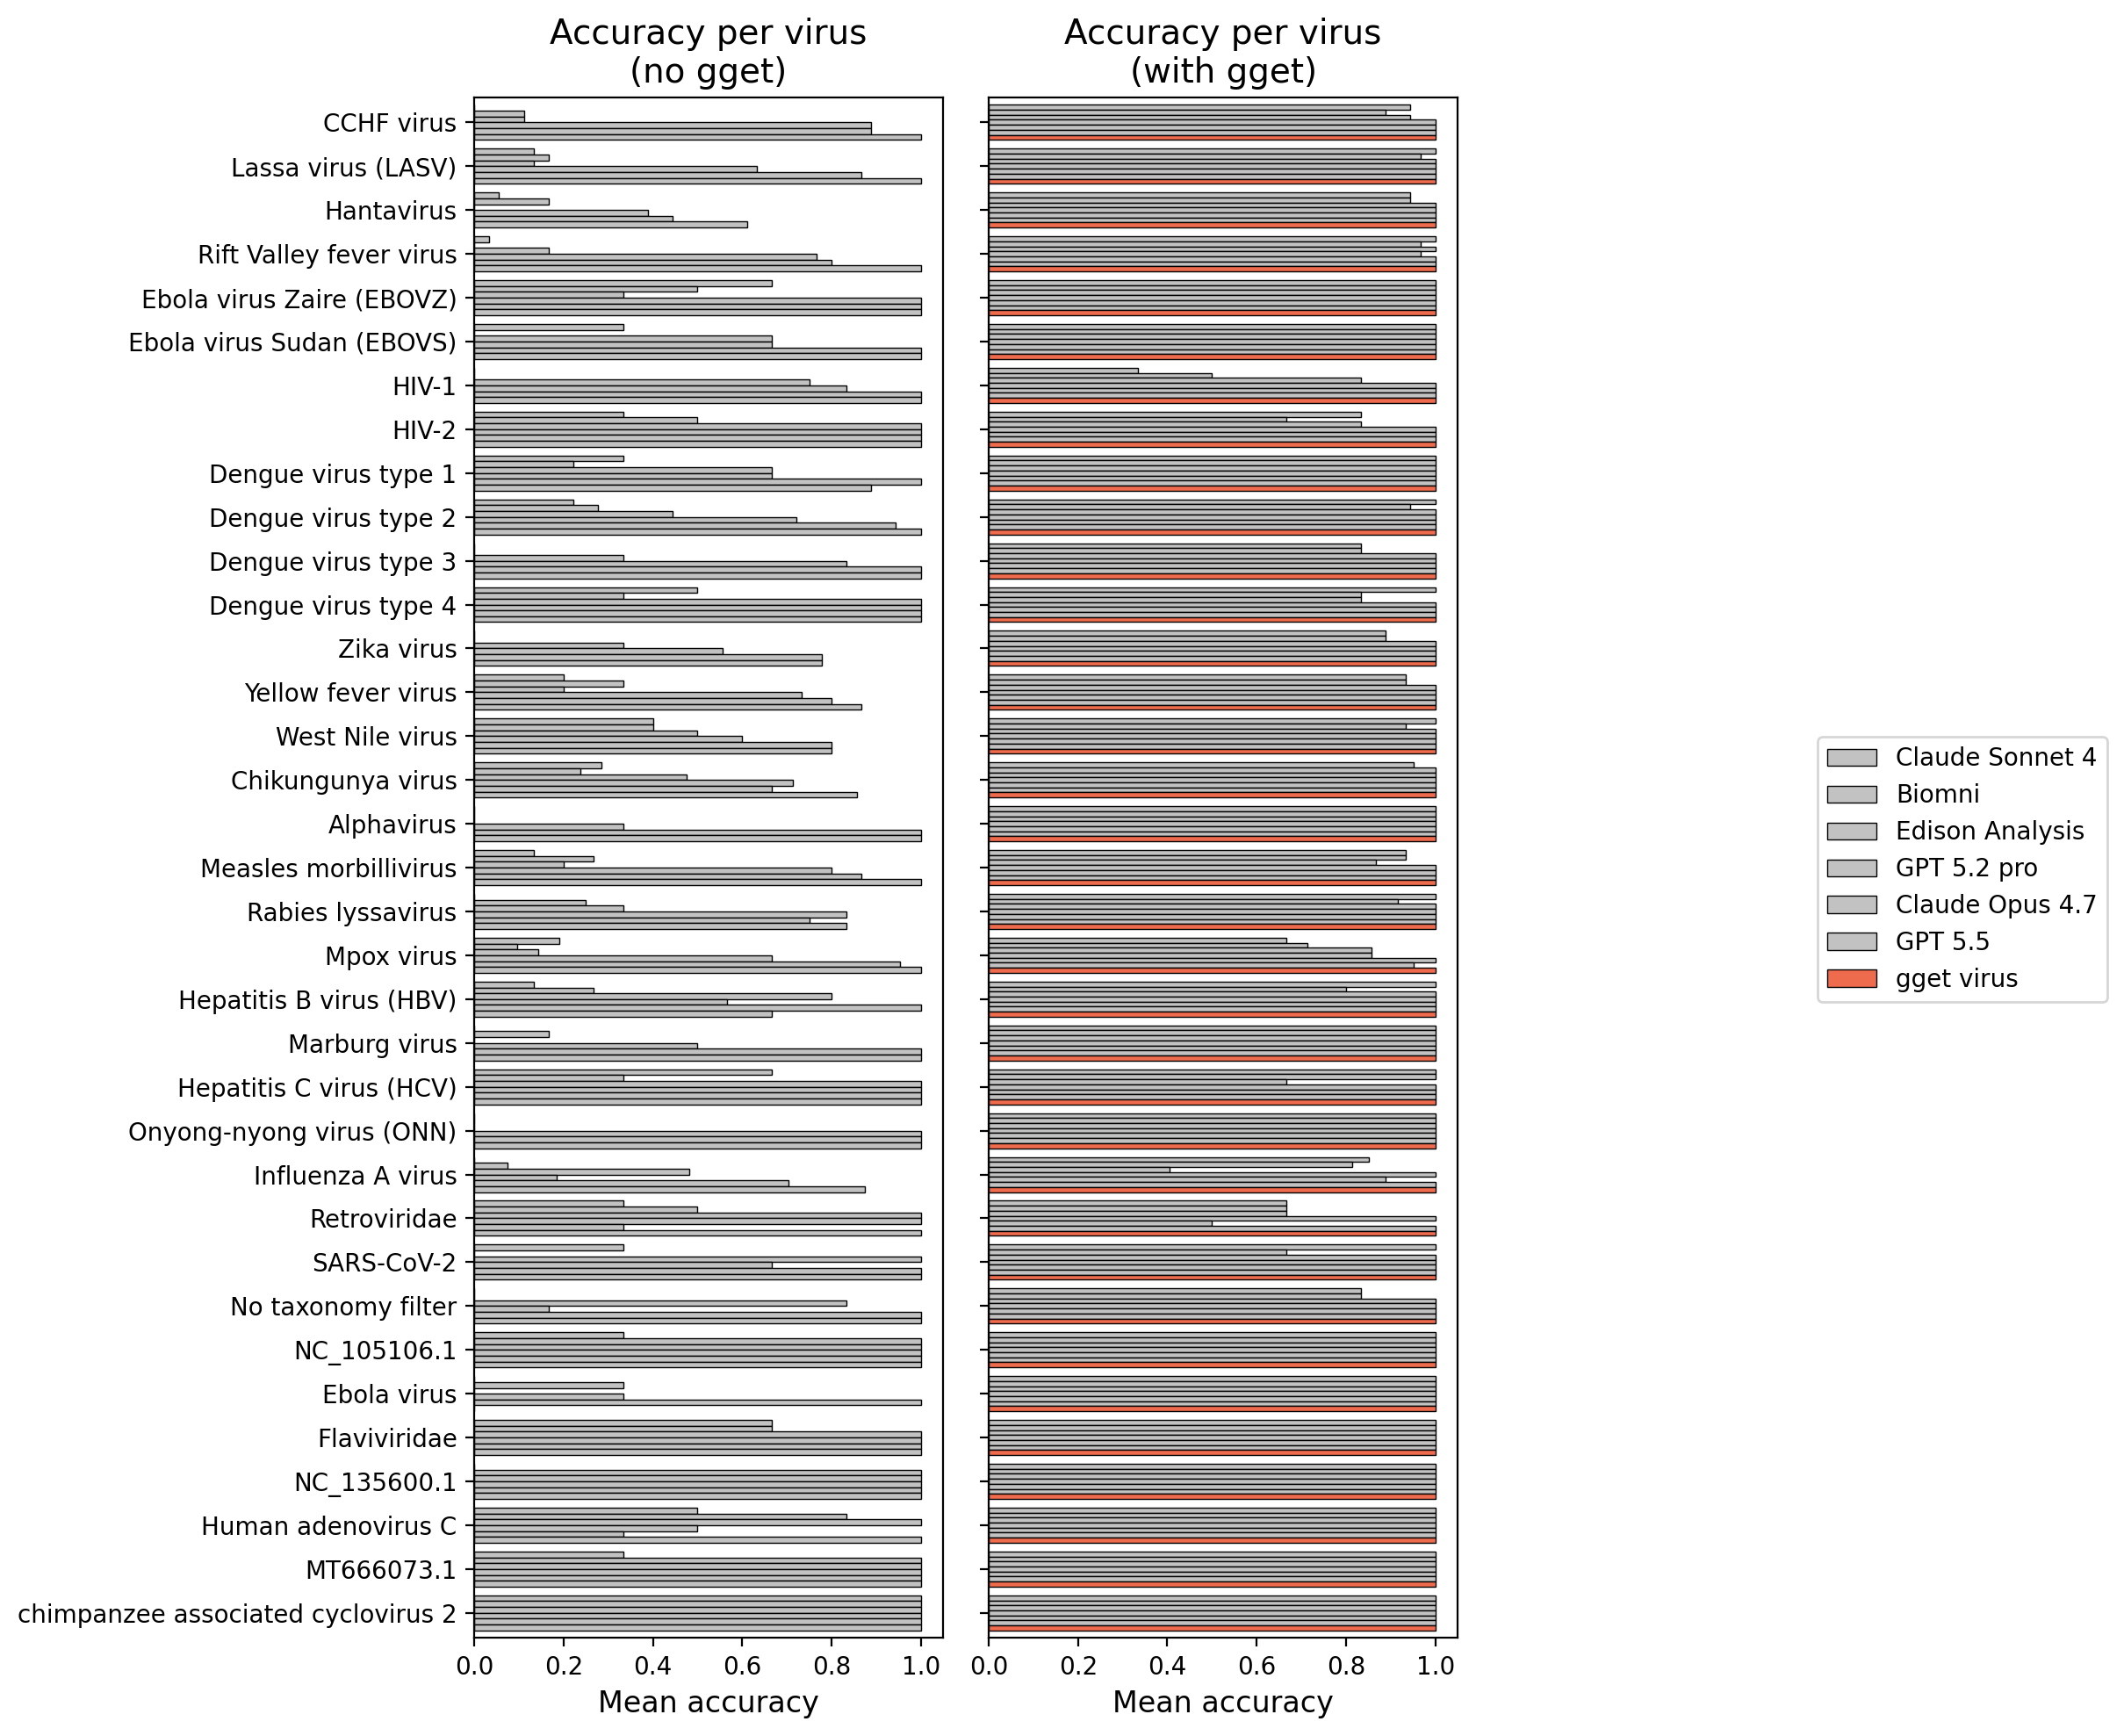

In [30]:
# LLM base names (without gget) — excluding "gget virus" standalone
llm_bases = [name for name in TECHNOLOGIES if "gget" not in name]
# Corresponding "+ gget" variants
llm_gget = [name + " + gget" for name in llm_bases]
# gget virus standalone
gget_virus_name = "gget virus"

# Technologies for left panel (LLMs without gget)
left_tech = llm_bases
# Technologies for right panel (LLMs with gget + gget virus direct)
right_tech = llm_gget + [gget_virus_name]

# Mean accuracy per pathogen for each technology
pathogen_acc = {}
for name in TECHNOLOGIES:
    qids = data[name]["query_ids"]
    acc = metrics[name]["accuracy"]
    qid_to_acc = dict(zip(qids, acc))
    tech_acc = []
    for pathogen in all_pathogens:
        vals = [qid_to_acc[qid] for qid in qid_to_acc if rename_pathogen(pathogen_map.get(qid, "")) == pathogen]
        tech_acc.append(np.nanmean(vals) if vals else np.nan)
    pathogen_acc[name] = tech_acc

n_pathogens = len(all_pathogens)
n_left = len(left_tech)
n_right = len(right_tech)

bar_height_left = 0.8 / n_left
bar_height_right = 0.8 / n_right
y = np.arange(n_pathogens)

fig, (ax0, ax1) = plt.subplots(1, 2, figsize=(10,10), width_ratios=[1, 1])

# Left panel: LLMs without gget
left_handles = []
for i, name in enumerate(left_tech):
    offsets = y + (i - n_left / 2 + 0.5) * bar_height_left
    bars = ax0.barh(offsets, pathogen_acc[name], height=bar_height_left,
                    color=COLORS[name], edgecolor="black", lw=0.5)
    left_handles.append((bars[0], name))

# Right panel: LLMs with gget + gget virus
right_handles = []
for i, name in enumerate(right_tech):
    offsets = y + (i - n_right / 2 + 0.5) * bar_height_right
    # Remove the hatch by simply not setting it
    bars = ax1.barh(offsets, pathogen_acc[name], height=bar_height_right,
                    color=COLORS[name], edgecolor="black", lw=0.5)
    right_handles.append((bars[0], name))

# Y-axis: pathogens on both panels (set on ax0, mirror on ax1)
ax0.set_yticks(y)
ax0.set_yticklabels(all_pathogens, fontsize=FONTSIZE - 2)
ax0.margins(y=0.005)
ax1.set_yticks(y)
ax1.set_yticklabels([])
ax1.margins(y=0.005)

ax0.set_xlabel("Mean accuracy", fontsize=FONTSIZE)
ax1.set_xlabel("Mean accuracy", fontsize=FONTSIZE)
ax0.set_xlim(0, 1.05)
ax1.set_xlim(0, 1.05)

ax0.set_title("Accuracy per virus\n(no gget)", fontsize=FONTSIZE + 2)
ax1.set_title("Accuracy per virus\n(with gget)", fontsize=FONTSIZE + 2)

ax0.tick_params(labelsize=FONTSIZE - 2)
ax1.tick_params(labelsize=FONTSIZE - 2)
ax0.invert_yaxis()
ax1.invert_yaxis()

# Build legend handles explicitly, but EXCLUDE labels with "+ gget"
legend_handles_labels = [
    (h, lbl) for (h, lbl) in left_handles + right_handles
    if "+ gget" not in lbl
]

if legend_handles_labels:
    legend_handles, legend_labels = zip(*legend_handles_labels)
else:
    legend_handles, legend_labels = [], []

fig.legend(
    legend_handles,
    legend_labels,
    fontsize=FONTSIZE - 2,
    bbox_to_anchor=(1.04, 0.5),
    loc='center left',
    borderaxespad=0
)

fig.tight_layout(rect=[0, 0, 0.85, 1])

/tmp/ipykernel_2360916/3717391614.py:134: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  fig.tight_layout(rect=[0, 0, 1, 1])


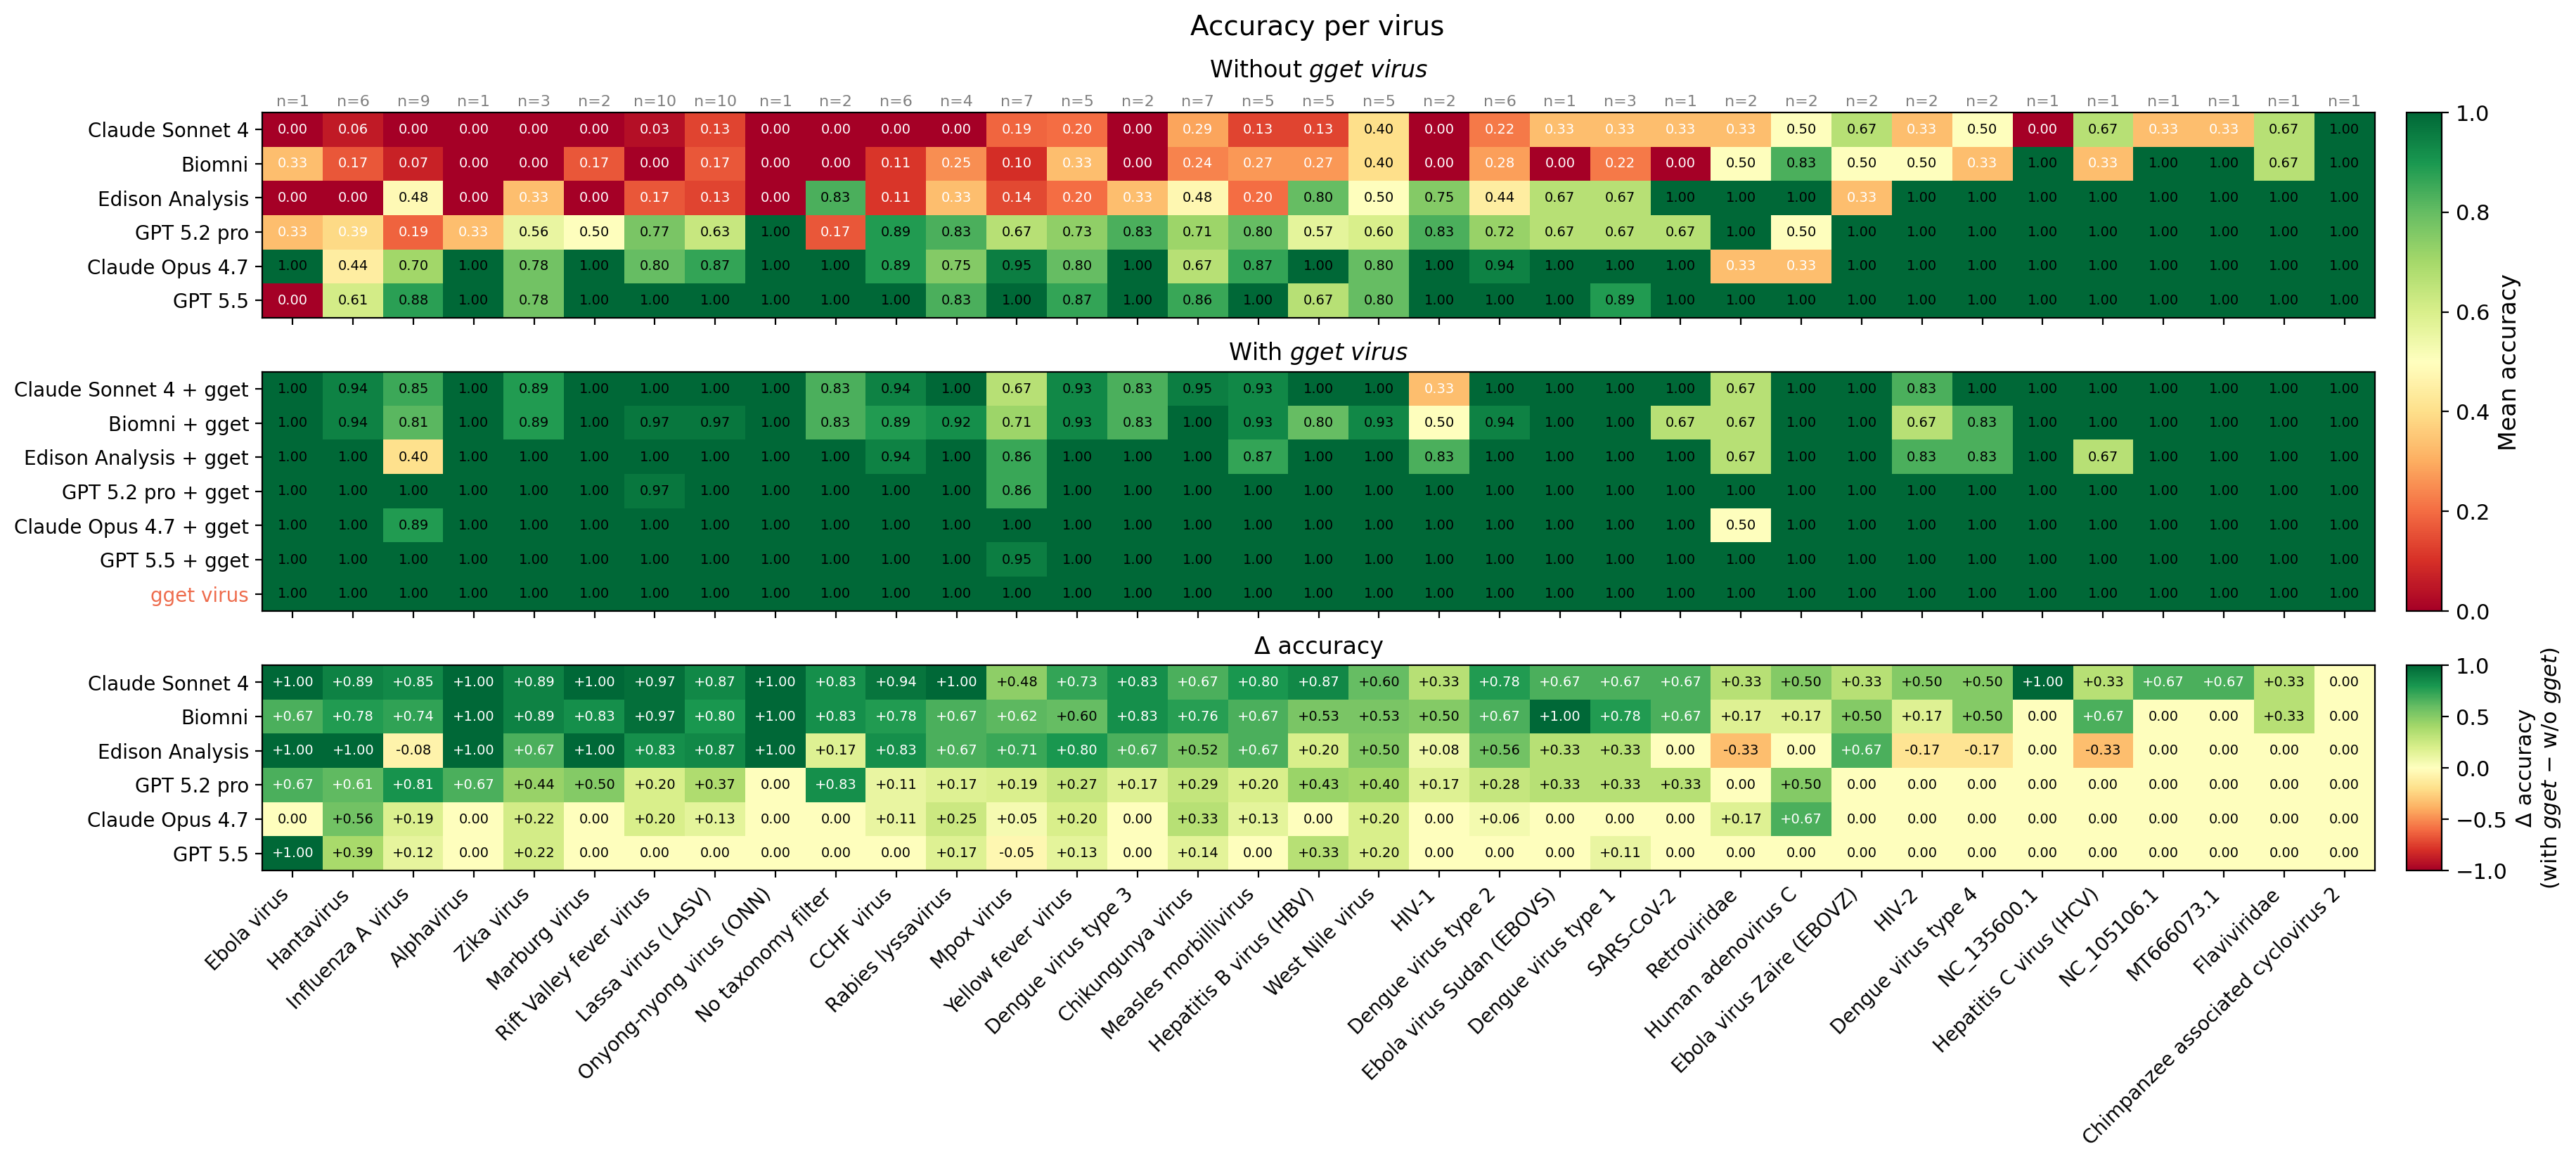

In [31]:
# Horizontal heatmap version of accuracy per virus
import matplotlib.colors as mcolors
from matplotlib import gridspec
from matplotlib.colorbar import Colorbar

# Sort pathogens by mean accuracy across no-gget LLMs (lowest to highest),
# tiebreak by Claude, Biomni, Edison, GPT (in that order)
no_gget_order = [name for name in left_tech if "+ gget" not in name and name != "gget virus"]
sort_keys = []
for i, p in enumerate(all_pathogens):
    accs = [pathogen_acc[name][i] for name in no_gget_order]
    mean_acc = np.nanmean(accs)
    sort_keys.append((mean_acc, *accs))

sort_idx = sorted(range(len(all_pathogens)), key=lambda i: sort_keys[i])
sorted_pathogens = [all_pathogens[i] for i in sort_idx]

# Count unique queries per (renamed) pathogen
queries_per_pathogen = {}
for qid, p in pathogen_map.items():
    rp = rename_pathogen(p)
    queries_per_pathogen.setdefault(rp, set()).add(qid)
n_queries_per_pathogen = [len(queries_per_pathogen.get(p, set())) for p in sorted_pathogens]

# Build matrices with sorted pathogen order: rows = technologies, cols = pathogens
left_matrix = np.array([pathogen_acc[name] for name in left_tech])[:, sort_idx]
right_matrix = np.array([pathogen_acc[name] for name in right_tech])[:, sort_idx]

# Compute gget delta matrix: rows = LLM bases, cols = sorted pathogens
n_bases = len(llm_bases)
delta_matrix = np.array([
    np.array(pathogen_acc[name + " + gget"]) - np.array(pathogen_acc[name])
    for name in llm_bases
])[:, sort_idx]

# Layout: 3 heatmap rows + 1 colorbar column
fig = plt.figure(figsize=(20, 7))
gs = gridspec.GridSpec(
    3, 2,
    width_ratios=[30, 0.5],
    height_ratios=[n_left, n_right, n_bases],
    wspace=0.03, 
    hspace=0.25,
)

ax0 = fig.add_subplot(gs[0, 0])
ax1 = fig.add_subplot(gs[1, 0], sharex=ax0)
ax2 = fig.add_subplot(gs[2, 0], sharex=ax0)
ax_cb_acc = fig.add_subplot(gs[0:2, 1])
ax_cb_delta = fig.add_subplot(gs[2, 1])

cmap = "RdYlGn"

# Panel A+B: mean accuracy
im0 = ax0.imshow(left_matrix, aspect="auto", cmap=cmap, vmin=0, vmax=1)
im1 = ax1.imshow(right_matrix, aspect="auto", cmap=cmap, vmin=0, vmax=1)

for mat, ax in [(left_matrix, ax0), (right_matrix, ax1)]:
    for i in range(mat.shape[0]):
        for j in range(mat.shape[1]):
            val = mat[i, j]
            if np.isnan(val):
                continue
            text_color = "white" if val < 0.4 else "black"
            ax.text(j, i, f"{val:.2f}", ha="center", va="center",
                    fontsize=FONTSIZE - 5, color=text_color)

# Panel C: gget delta
im2 = ax2.imshow(delta_matrix, aspect="auto", cmap=cmap, vmin=-1, vmax=1)

for i in range(delta_matrix.shape[0]):
    for j in range(delta_matrix.shape[1]):
        val = delta_matrix[i, j]
        if np.isnan(val):
            continue
        tc = "white" if abs(val) > 0.6 else "black"
        sign = "+" if val > 0 else ""
        ax2.text(j, i, f"{sign}{val:.2f}", ha="center", va="center",
                 fontsize=FONTSIZE - 5, color=tc)

# Titles
ax0.set_title("Without $\\it{gget}$ $\\it{virus}$", fontsize=FONTSIZE, pad=18)
ax1.set_title("With $\\it{gget}$ $\\it{virus}$", fontsize=FONTSIZE)
ax2.set_title("Δ accuracy", fontsize=FONTSIZE)

fig.suptitle("Accuracy per virus", fontsize=FONTSIZE + 2, y=0.98)

# Y-axis labels
ax0.set_yticks(range(n_left))
ax0.set_yticklabels(left_tech, fontsize=FONTSIZE - 2)
ax1.set_yticks(range(n_right))
ax1.set_yticklabels(right_tech, fontsize=FONTSIZE - 2)
for label in ax1.get_yticklabels():
    if "gget virus" == label.get_text():
        label.set_color(COLORS["gget virus"])
ax2.set_yticks(range(n_bases))
ax2.set_yticklabels(llm_bases, fontsize=FONTSIZE - 2)

# X-axis: hide on top two, show on bottom
ax0.set_xticks(range(len(sorted_pathogens)))
ax0.set_xticklabels([])
ax0.tick_params(axis='x', which='both', bottom=True, top=False, labelbottom=False, labeltop=False)

ax1.set_xticks(range(len(sorted_pathogens)))
ax1.set_xticklabels([])
ax1.tick_params(axis='x', which='both', bottom=True, top=False, labelbottom=False, labeltop=False)

ax2.set_xticks(range(len(sorted_pathogens)))
ax2.set_xticklabels([p[0].upper() + p[1:] if p else p for p in sorted_pathogens], fontsize=FONTSIZE - 2, rotation=45, ha="right")

# Show number of queries above each column
for j, nq in enumerate(n_queries_per_pathogen):
    ax0.text(j, -0.6, f"n={nq}", ha="center", va="bottom",
             fontsize=FONTSIZE - 4, color="gray")

# Colorbar for accuracy (panels A+B)
cb_acc = fig.colorbar(im1, cax=ax_cb_acc, orientation="vertical")
ax_cb_acc.yaxis.set_label_position('right')
ax_cb_acc.tick_params(labelsize=FONTSIZE - 1, left=False, right=True, labelleft=False, labelright=True)
ax_cb_acc.set_ylabel("Mean accuracy", fontsize=FONTSIZE)
cb_acc.ax.set_title("")
for spine in ["top", "bottom", "left"]:
    ax_cb_acc.spines[spine].set_visible(False)

# Colorbar for delta (panel C)
cb_delta = fig.colorbar(im2, cax=ax_cb_delta, orientation="vertical")
ax_cb_delta.yaxis.set_label_position('right')
ax_cb_delta.tick_params(labelsize=FONTSIZE - 1, left=False, right=True, labelleft=False, labelright=True)
ax_cb_delta.set_ylabel("Δ accuracy\n(with $\\it{gget}$ − w/o $\\it{gget}$)", fontsize=FONTSIZE - 1)
for spine in ["top", "bottom", "left"]:
    ax_cb_delta.spines[spine].set_visible(False)


fig.tight_layout(rect=[0, 0, 1, 1])

fig.savefig("../figures/heatmap_accuracy.png", dpi=300, bbox_inches="tight")


In [32]:
def plot_metric_heatmap(metric_key, title, cbar_label, cmap="RdYlGn", vmin=0, vmax=1, fmt=".2f",
                        invert_cmap=False, text_thresh=None, transform=None):
    """Plot a two-panel heatmap (no gget / with gget) for any per-query metric."""
    # Compute mean metric per pathogen for each technology
    pathogen_metric = {}
    for name in TECHNOLOGIES:
        qids = data[name]["query_ids"]
        vals_arr = metrics[name][metric_key]
        qid_to_val = dict(zip(qids, vals_arr))
        tech_vals = []
        for pathogen in all_pathogens:
            vals = [qid_to_val[qid] for qid in qid_to_val if rename_pathogen(pathogen_map.get(qid, "")) == pathogen]
            mean_val = np.nanmean(vals) if vals else np.nan
            if transform is not None and not np.isnan(mean_val):
                mean_val = transform(mean_val)
            tech_vals.append(mean_val)
        pathogen_metric[name] = tech_vals

    left_matrix = np.array([pathogen_metric[name] for name in left_tech])[:, sort_idx]
    right_matrix = np.array([pathogen_metric[name] for name in right_tech])[:, sort_idx]

    used_cmap = cmap + "_r" if invert_cmap else cmap

    fig = plt.figure(figsize=(16, 5))
    gs = gridspec.GridSpec(2, 2, width_ratios=[30, 0.5], height_ratios=[n_left, n_right], wspace=0.05, hspace=0.15)
    ax0 = fig.add_subplot(gs[0, 0])
    ax1 = fig.add_subplot(gs[1, 0], sharex=ax0)
    ax_cb = fig.add_subplot(gs[:, 1])

    im0 = ax0.imshow(left_matrix, aspect="auto", cmap=used_cmap, vmin=vmin, vmax=vmax)
    im1 = ax1.imshow(right_matrix, aspect="auto", cmap=used_cmap, vmin=vmin, vmax=vmax)

    # Determine text color threshold
    if text_thresh is None:
        text_thresh = (vmin + vmax) / 2

    for mat, ax in [(left_matrix, ax0), (right_matrix, ax1)]:
        for i in range(mat.shape[0]):
            for j in range(mat.shape[1]):
                val = mat[i, j]
                if np.isnan(val):
                    continue
                if invert_cmap:
                    text_color = "white" if val > text_thresh else "black"
                else:
                    text_color = "white" if val < text_thresh else "black"
                ax.text(j, i, f"{val:{fmt}}", ha="center", va="center",
                        fontsize=FONTSIZE - 5, color=text_color)

    ax0.set_yticks(range(n_left))
    ax0.set_yticklabels(left_tech, fontsize=FONTSIZE - 2)
    ax1.set_yticks(range(n_right))
    ax1.set_yticklabels(right_tech, fontsize=FONTSIZE - 2)
    for label in ax1.get_yticklabels():
        if "gget virus" == label.get_text():
            label.set_color(COLORS["gget virus"])

    ax0.set_xticks(range(len(sorted_pathogens)))
    ax0.set_xticklabels([])
    ax0.tick_params(axis='x', which='both', bottom=True, top=False, labelbottom=False, labeltop=False)

    ax1.set_xticks(range(len(sorted_pathogens)))
    ax1.set_xticklabels([p[0].upper() + p[1:] if p else p for p in sorted_pathogens],
                        fontsize=FONTSIZE - 2, rotation=45, ha="right")

    ax0.set_title(title, fontsize=FONTSIZE + 2, pad=20)

    for j, nq in enumerate(n_queries_per_pathogen):
        ax0.text(j, -0.6, f"n={nq}", ha="center", va="bottom",
                 fontsize=FONTSIZE - 4, color="gray")

    cb = fig.colorbar(im1, cax=ax_cb, orientation="vertical")
    ax_cb.yaxis.set_label_position('right')
    ax_cb.tick_params(labelsize=FONTSIZE - 1, left=False, right=True, labelleft=False, labelright=True)
    ax_cb.set_ylabel(cbar_label, fontsize=FONTSIZE)
    for spine in ["top", "bottom", "left"]:
        ax_cb.spines[spine].set_visible(False)

    fig.subplots_adjust(wspace=0.03, hspace=0.12)
    fig.tight_layout(rect=[0, 0, 1, 1])
    return fig

print("plot_metric_heatmap() defined")

plot_metric_heatmap() defined


/tmp/ipykernel_2360916/1965640016.py:80: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  fig.tight_layout(rect=[0, 0, 1, 1])


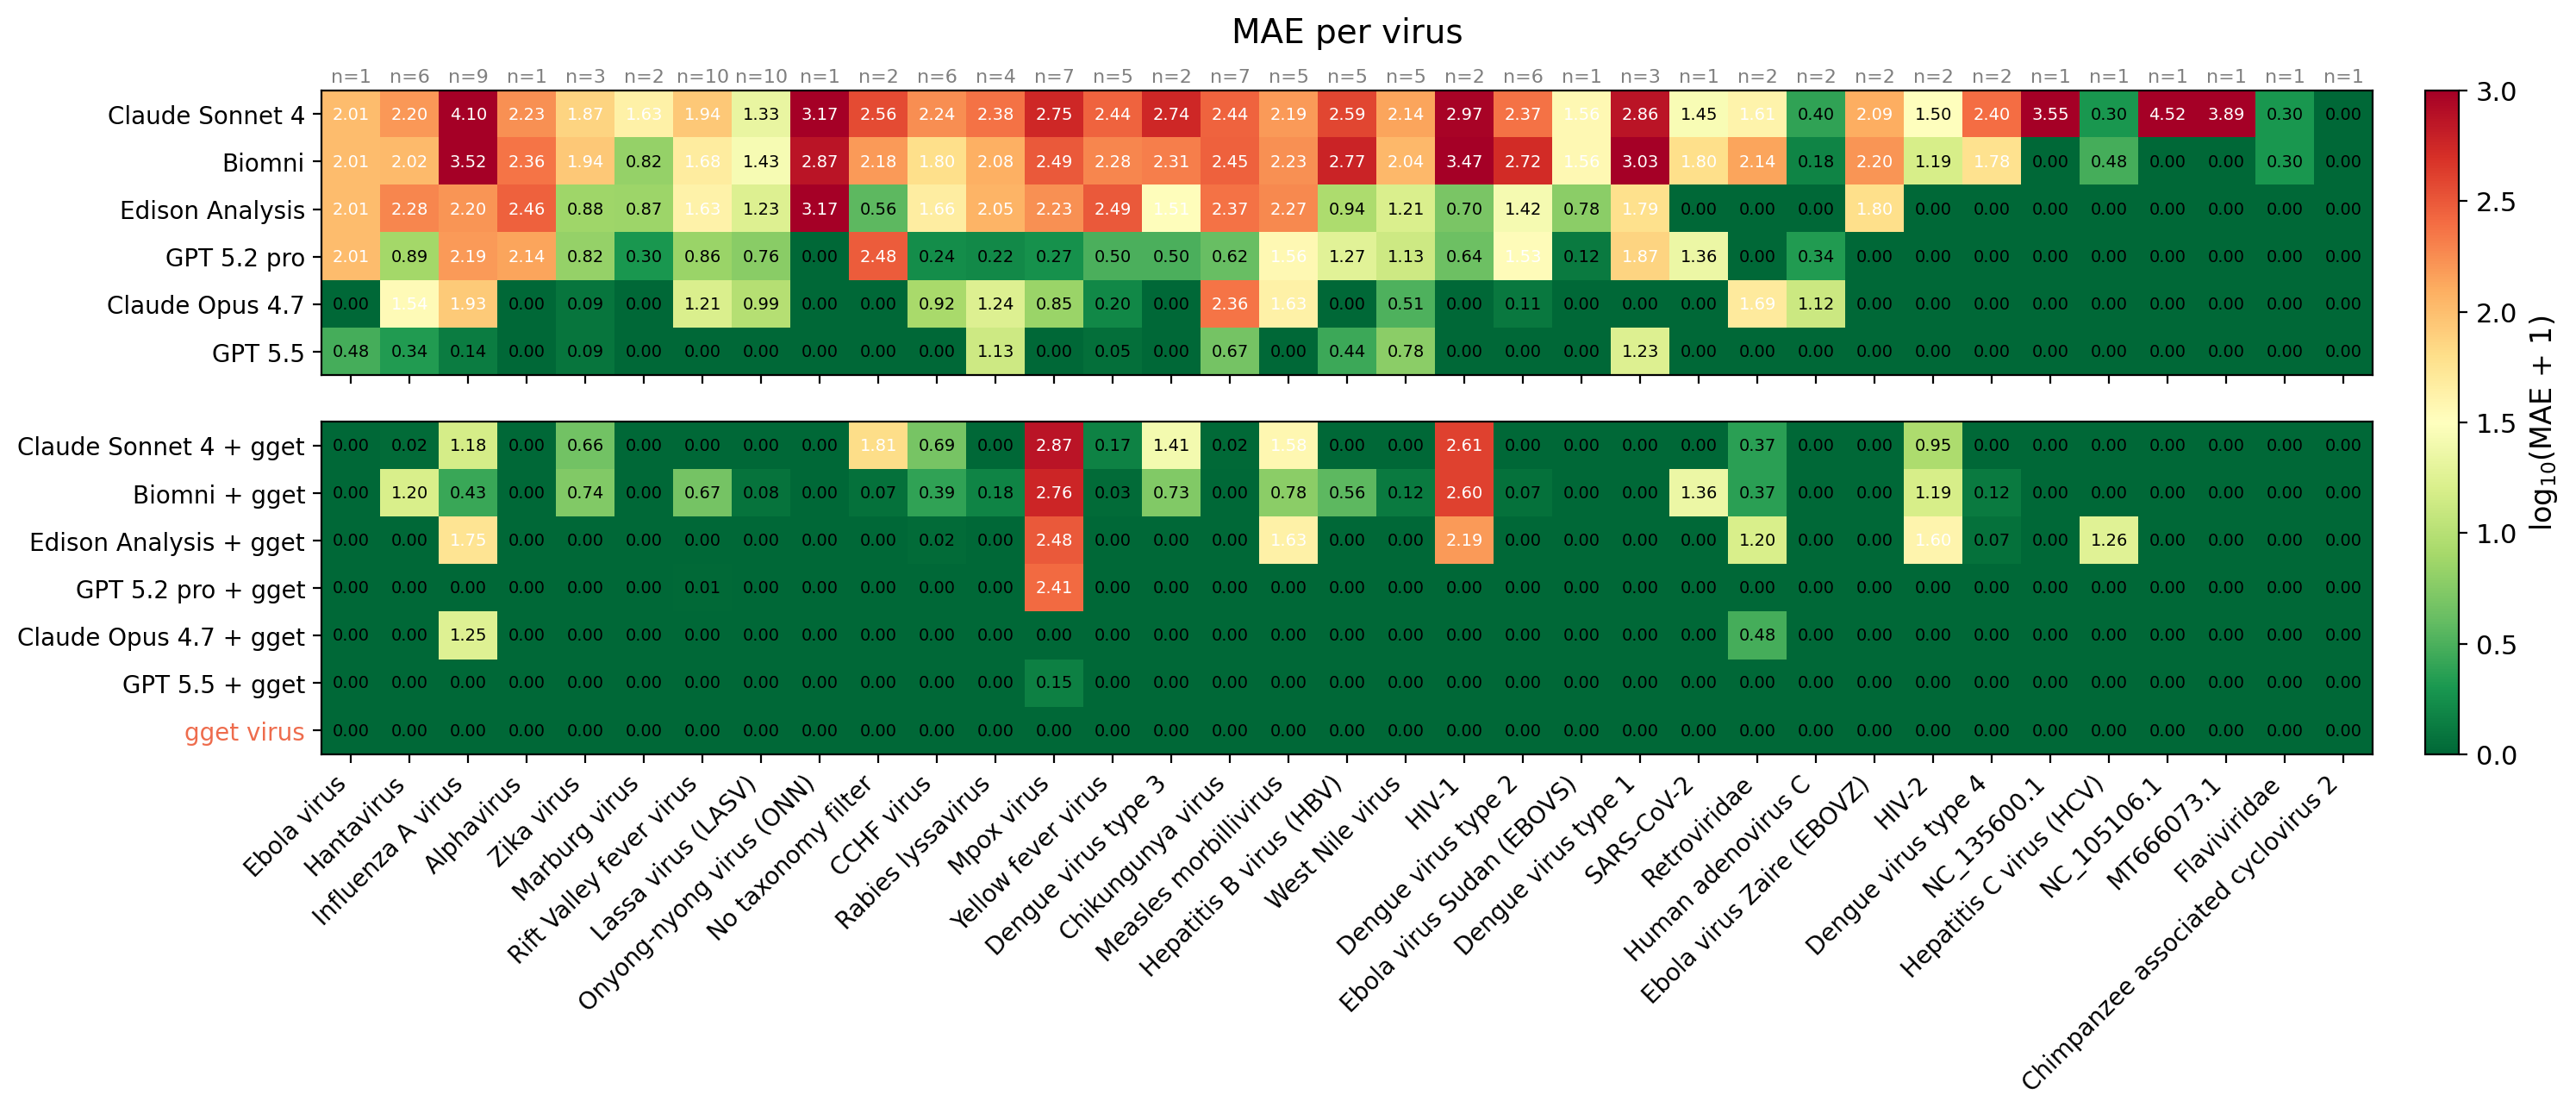

In [33]:
fig = plot_metric_heatmap(
    "mae", "MAE per virus", "log$_{10}$(MAE + 1)",
    cmap="RdYlGn", vmin=0, vmax=3, fmt=".2f", invert_cmap=True, text_thresh=1.5,
    transform=lambda x: np.log10(x + 1)
)
fig.savefig("../figures/heatmap_mae.png", dpi=300, bbox_inches="tight")

/tmp/ipykernel_2360916/1965640016.py:80: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  fig.tight_layout(rect=[0, 0, 1, 1])


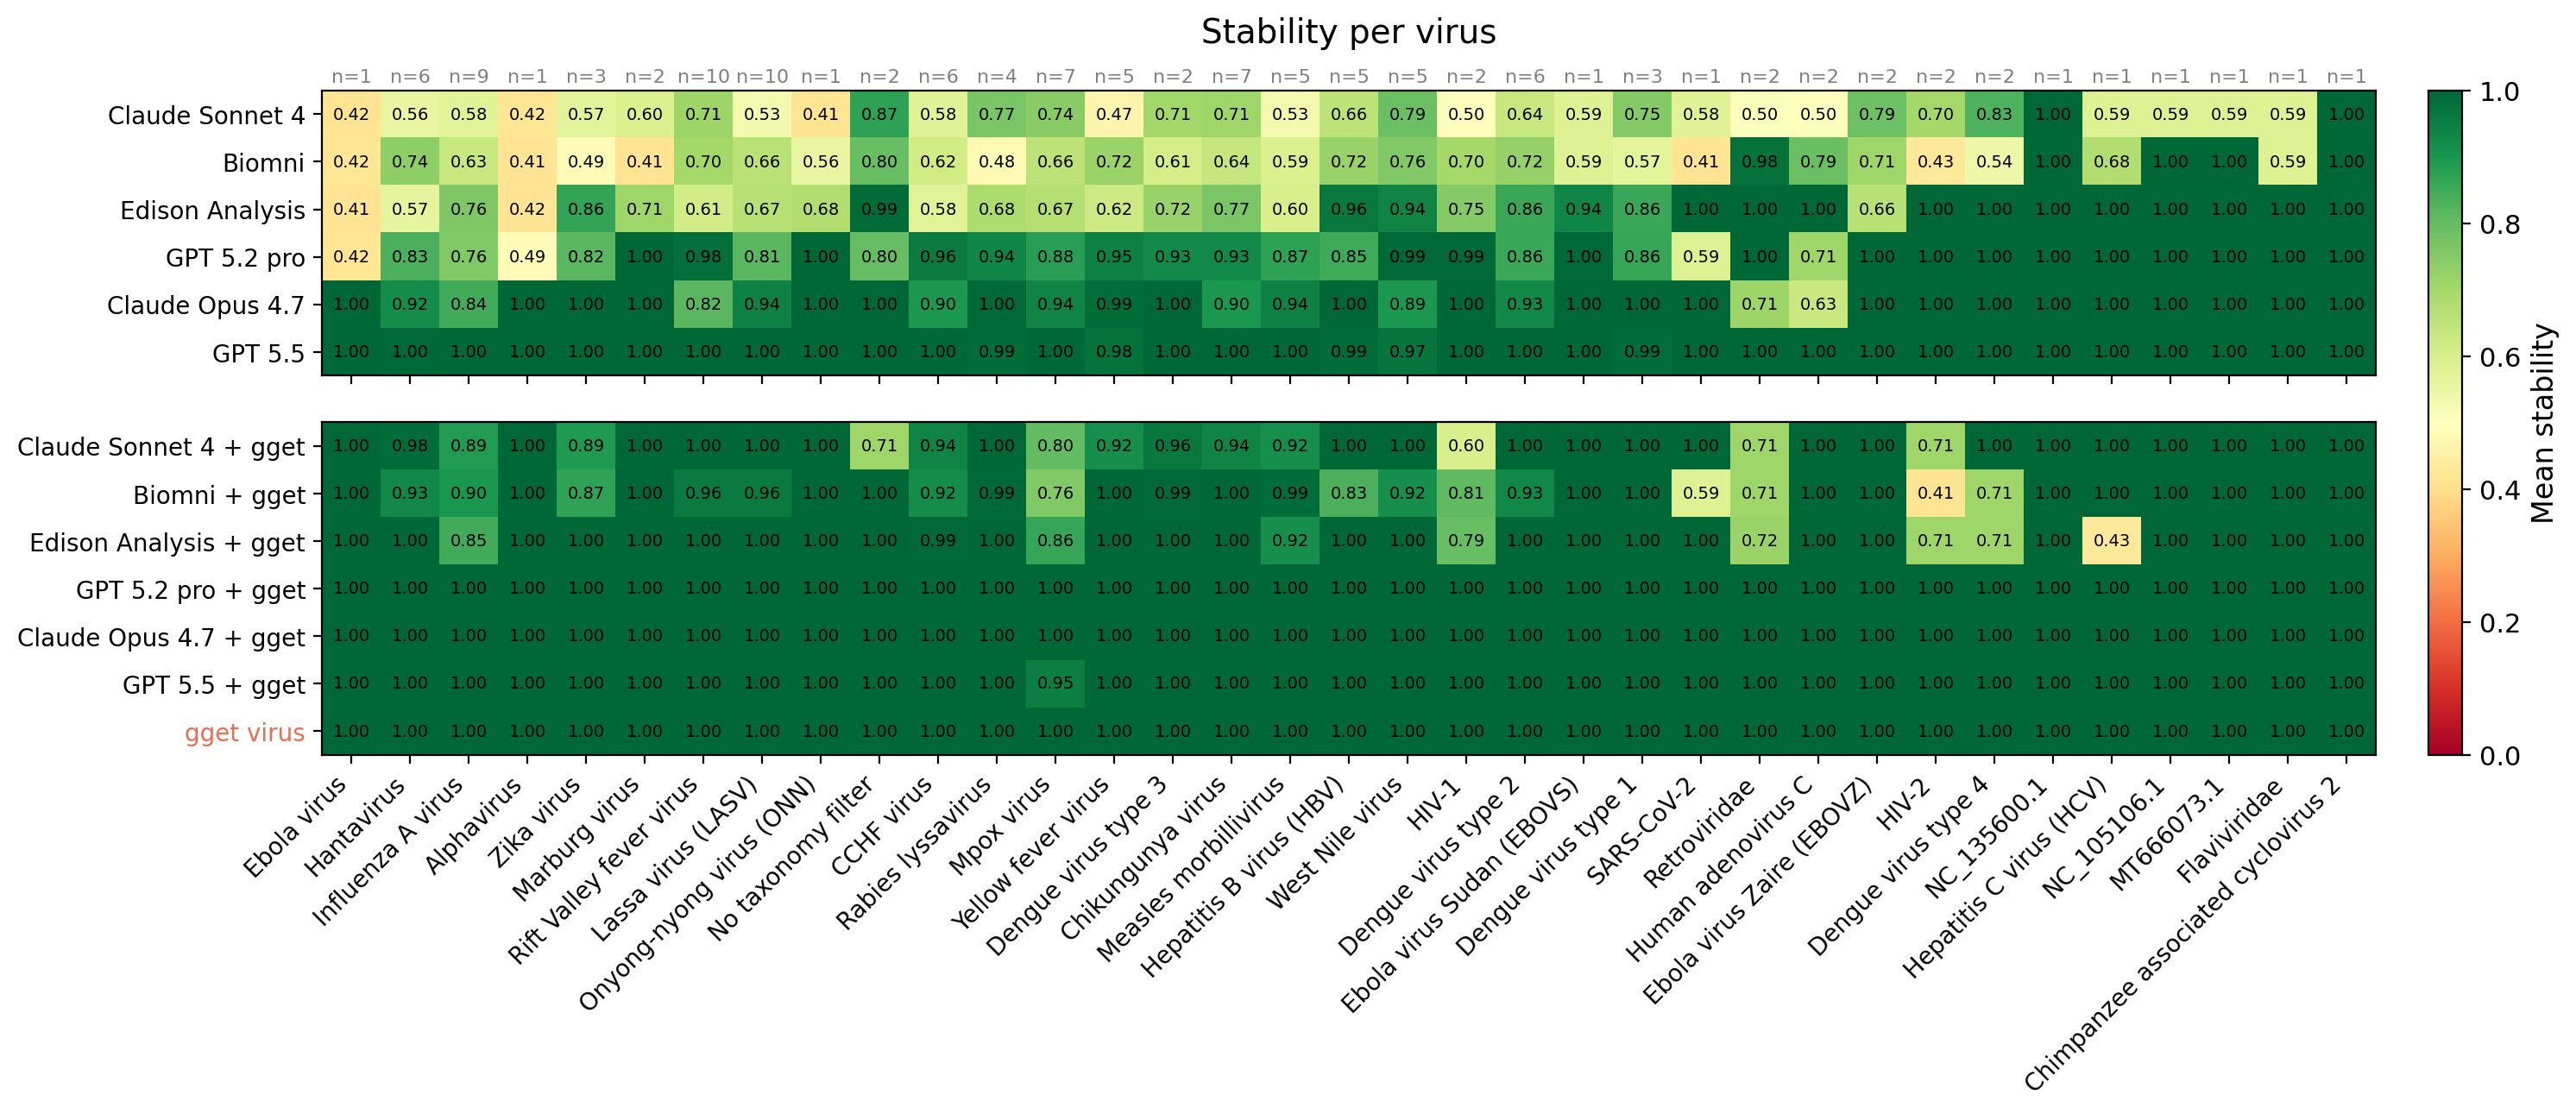

In [34]:
fig = plot_metric_heatmap(
    "stability", "Stability per virus", "Mean stability",
    cmap="RdYlGn", vmin=0, vmax=1, fmt=".2f", text_thresh=0.4
)
fig.savefig("../figures/heatmap_stability.png", dpi=300, bbox_inches="tight")

/tmp/ipykernel_2360916/1965640016.py:80: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  fig.tight_layout(rect=[0, 0, 1, 1])


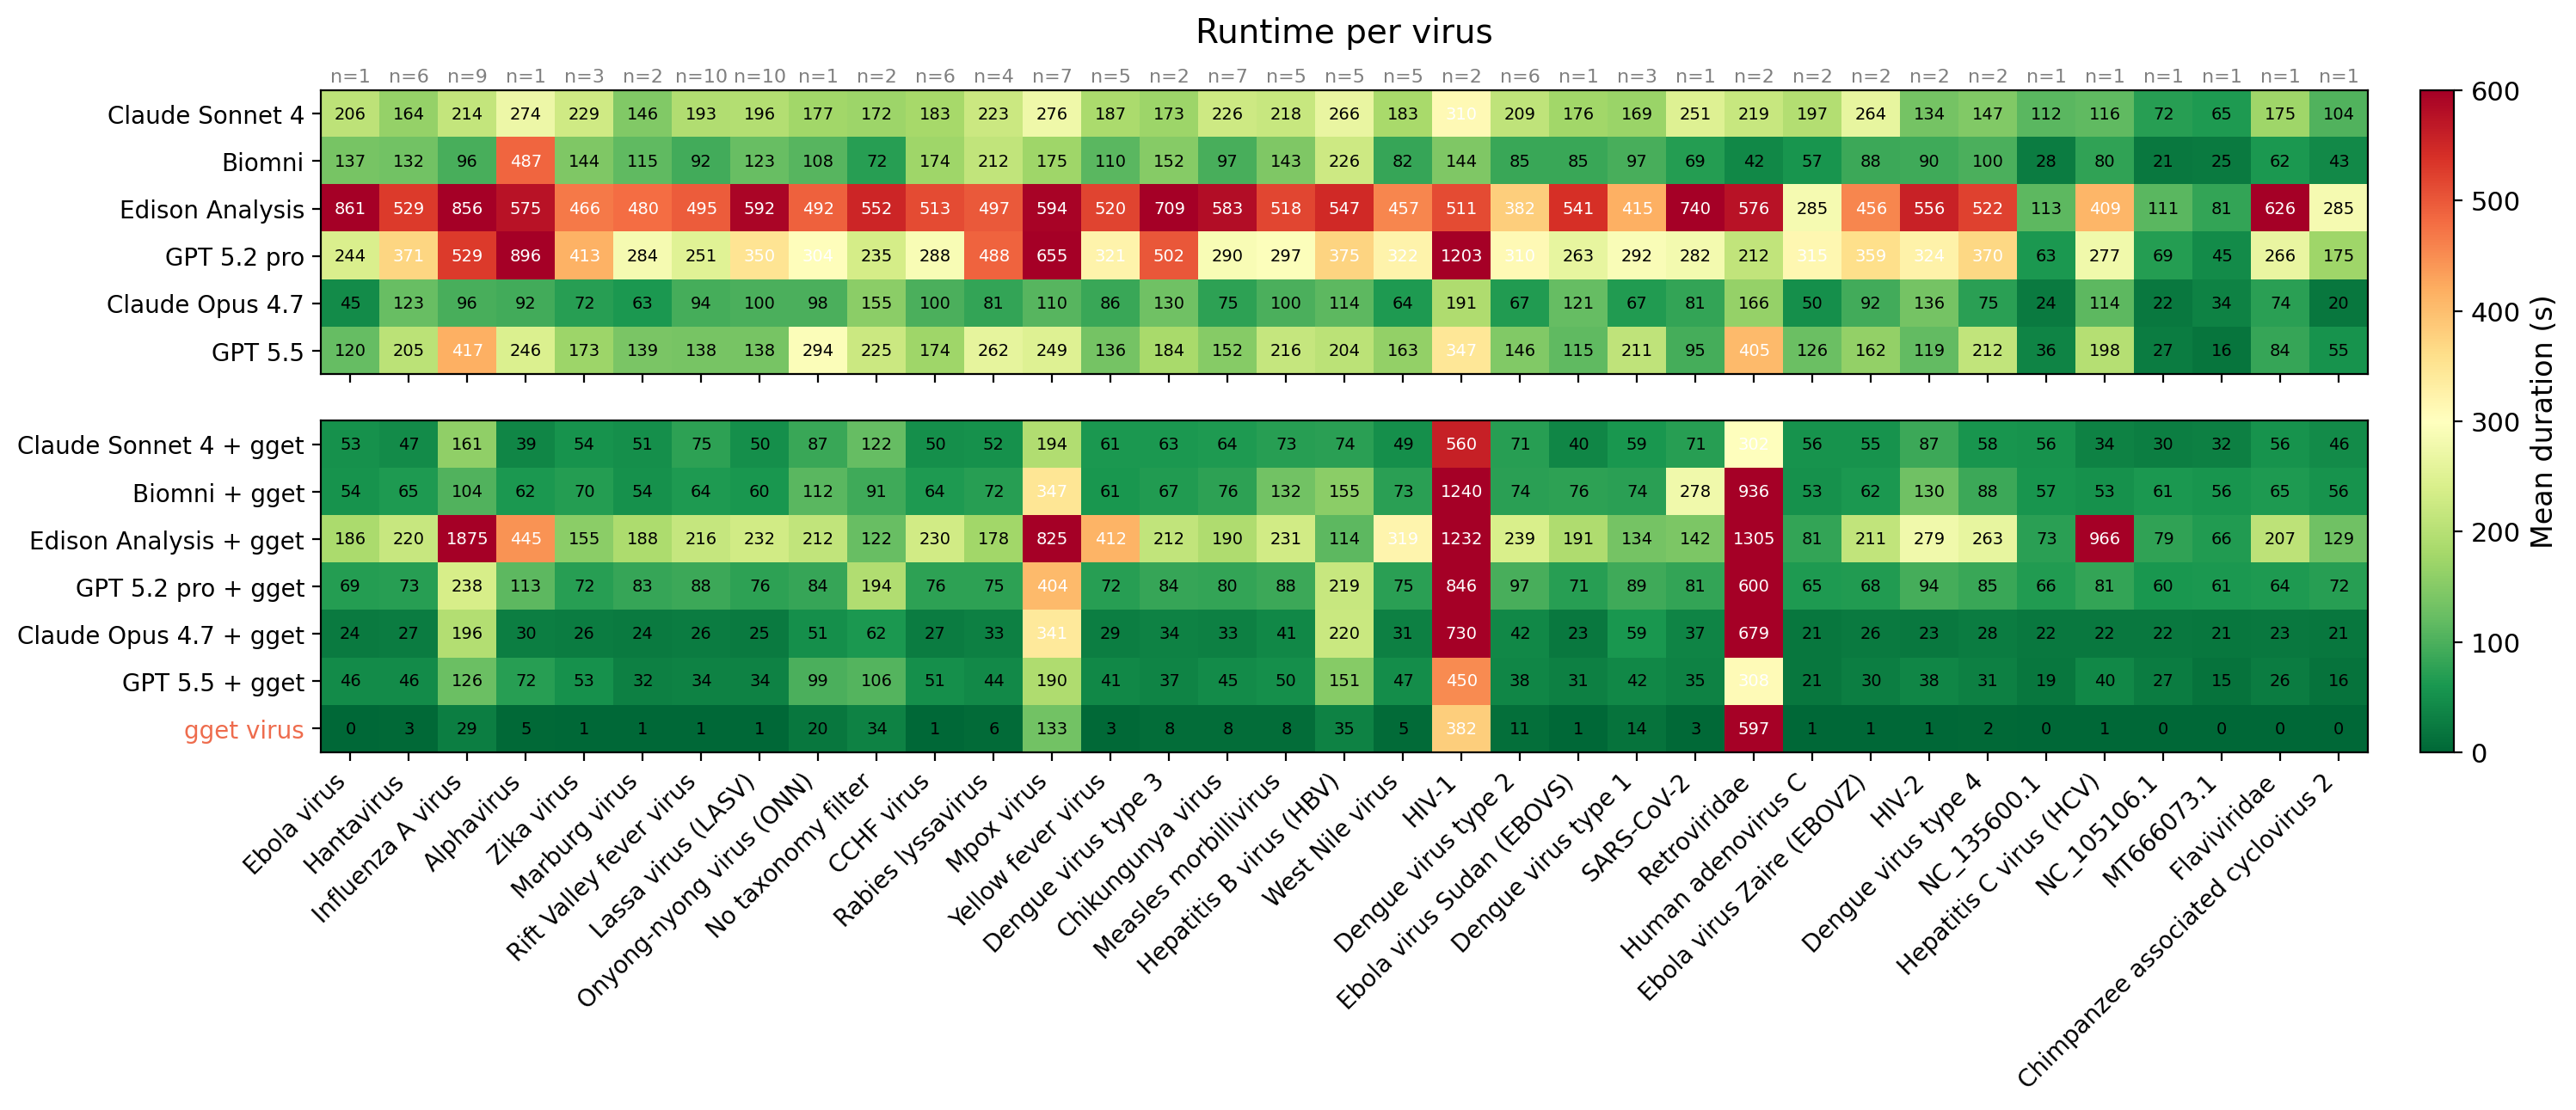

In [35]:
fig = plot_metric_heatmap(
    "duration", "Runtime per virus", "Mean duration (s)",
    cmap="RdYlGn", vmin=0, vmax=600, fmt=".0f", invert_cmap=True, text_thresh=300
)
fig.savefig("../figures/heatmap_duration.png", dpi=300, bbox_inches="tight")

Make sure agents know how to use gget correctly (add note about error logs)

# Histograms

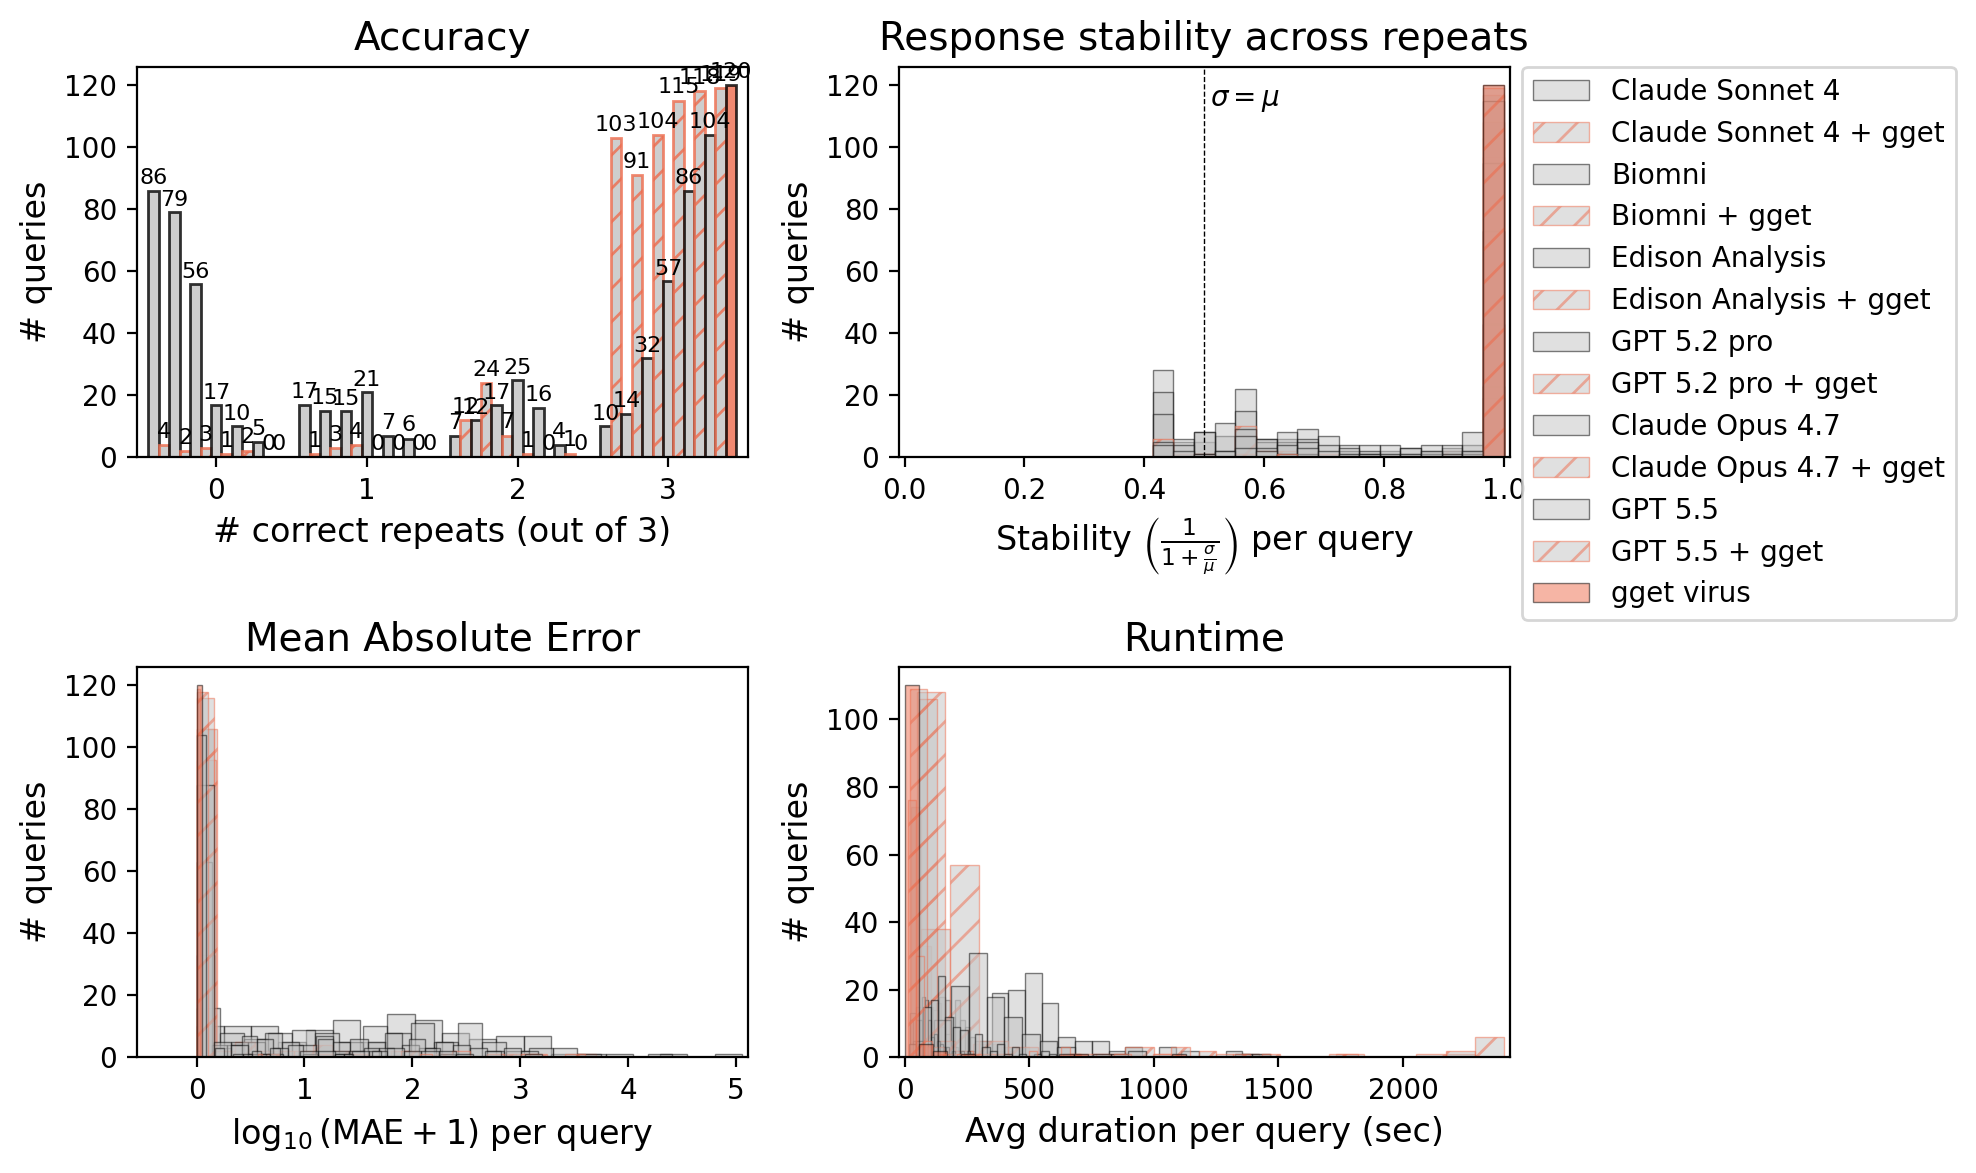

In [36]:
def apply_hist_hatch(patches, name):
    """Apply hatch pattern to histogram patches if defined for this technology."""
    pattern = HATCH.get(name)
    if pattern:
        for patch in patches:
            patch.set_hatch(pattern)
            patch.set_edgecolor(COLORS["gget virus"])


fig, axes = plt.subplots(2, 2, figsize=(10, 6))

# Top-left: Accuracy histogram (grouped bars)
ax = axes[0, 0]
accuracy_bin_edges = np.array([-0.16, 0.16, 0.5, 0.83, 1.16])
bin_labels = ["0", "1", "2", "3"]
n_tech = len(TECHNOLOGIES)
group_width = 0.9
bar_width = group_width / n_tech
x = np.arange(4)
for idx, name in enumerate(TECHNOLOGIES):
    acc_raw = np.array(metrics[name]["accuracy"])
    acc_vals = acc_raw[~np.isnan(acc_raw)]
    bin_counts, _ = np.histogram(acc_vals, bins=accuracy_bin_edges)
    bar_pos = x - ((group_width - bar_width) / 2) + idx * bar_width
    bars = ax.bar(bar_pos, bin_counts, width=bar_width, color=COLORS[name], label=name,
                  alpha=0.8, edgecolor="black", lw=1.0)
    apply_hist_hatch(bars, name)
    for b, count in zip(bar_pos, bin_counts):
        ax.text(b, count + (max(bin_counts) * 0.01 if len(bin_counts) > 0 else 0.1), str(count),
                ha="center", va="bottom", fontsize=FONTSIZE - 4)
ax.set_xticks(x)
ax.set_xticklabels(bin_labels, fontsize=FONTSIZE)
ax.set_xlabel("# correct repeats (out of 3)", fontsize=FONTSIZE)
ax.set_ylabel("# queries", fontsize=FONTSIZE)
ax.set_title("Accuracy", fontsize=FONTSIZE + 2)
ax.tick_params(labelsize=FONTSIZE - 2)
ax.margins(x=0.02)
# ax.set_ylim(top=58)

# Top-right: Stability histogram
ax = axes[0, 1]
bins = np.linspace(0, 1, 30)
for name in TECHNOLOGIES:
    _, _, patches = ax.hist(metrics[name]["stability"], bins=bins,
                            edgecolor="black", lw=0.5, alpha=0.5, color=COLORS[name],
                            label=name, histtype="bar", align="mid")
    apply_hist_hatch(patches, name)
ax.axvline(0.5, color="black", linestyle="--", linewidth=0.5)
ax.text(0.51, ax.get_ylim()[1] * 0.95, r"$\sigma = \mu$", fontsize=FONTSIZE - 2,
        va="top", ha="left")
ax.set_xlabel(r"Stability $\left(\frac{1}{1 + \frac{\sigma}{\mu}}\right)$ per query", fontsize=FONTSIZE)
ax.set_ylabel("# queries", fontsize=FONTSIZE)
ax.set_title("Response stability across repeats", fontsize=FONTSIZE + 2)
ax.tick_params(labelsize=FONTSIZE - 2)
# ax.set_xlim(0.3, 1)
ax.margins(x=0.01)

ax.legend(fontsize=FONTSIZE - 2, bbox_to_anchor=(1.02, 1), loc='upper left', borderaxespad=0)

# Bottom-left: MAE histogram
ax = axes[1, 0]
for name in TECHNOLOGIES:
    _, _, patches = ax.hist(np.log10(metrics[name]["mae"] + 1.0), bins=20,
                            edgecolor="black", lw=0.5, alpha=0.5, color=COLORS[name], label=name)
    apply_hist_hatch(patches, name)
ax.set_xlabel(r"$\log_{10}(\mathrm{MAE} + 1)$ per query", fontsize=FONTSIZE)
ax.set_ylabel("# queries", fontsize=FONTSIZE)
ax.set_title("Mean Absolute Error", fontsize=FONTSIZE + 2)
ax.tick_params(labelsize=FONTSIZE - 2)
# ax.set_xlim(-0.05)
ax.margins(x=0.01)

# Bottom-right: Duration histogram
ax = axes[1, 1]
for name in TECHNOLOGIES:
    _, _, patches = ax.hist(metrics[name]["duration"], bins=20,
                            edgecolor="black", lw=0.5, alpha=0.5, color=COLORS[name], label=name)
    apply_hist_hatch(patches, name)
ax.set_xlabel("Avg duration per query (sec)", fontsize=FONTSIZE)
ax.set_ylabel("# queries", fontsize=FONTSIZE)
ax.set_title("Runtime", fontsize=FONTSIZE + 2)
ax.tick_params(labelsize=FONTSIZE - 2)
ax.margins(x=0.01)

fig.tight_layout()
fig.savefig("../figures/histograms.png", dpi=300, bbox_inches="tight")

# Error magnitude
per run:  
error = prediction − expected  
Plot Histogram of absolute error

/tmp/ipykernel_2360916/472388467.py:11: UserWarning: Tight layout not applied. The bottom and top margins cannot be made large enough to accommodate all Axes decorations.
  fig.tight_layout()


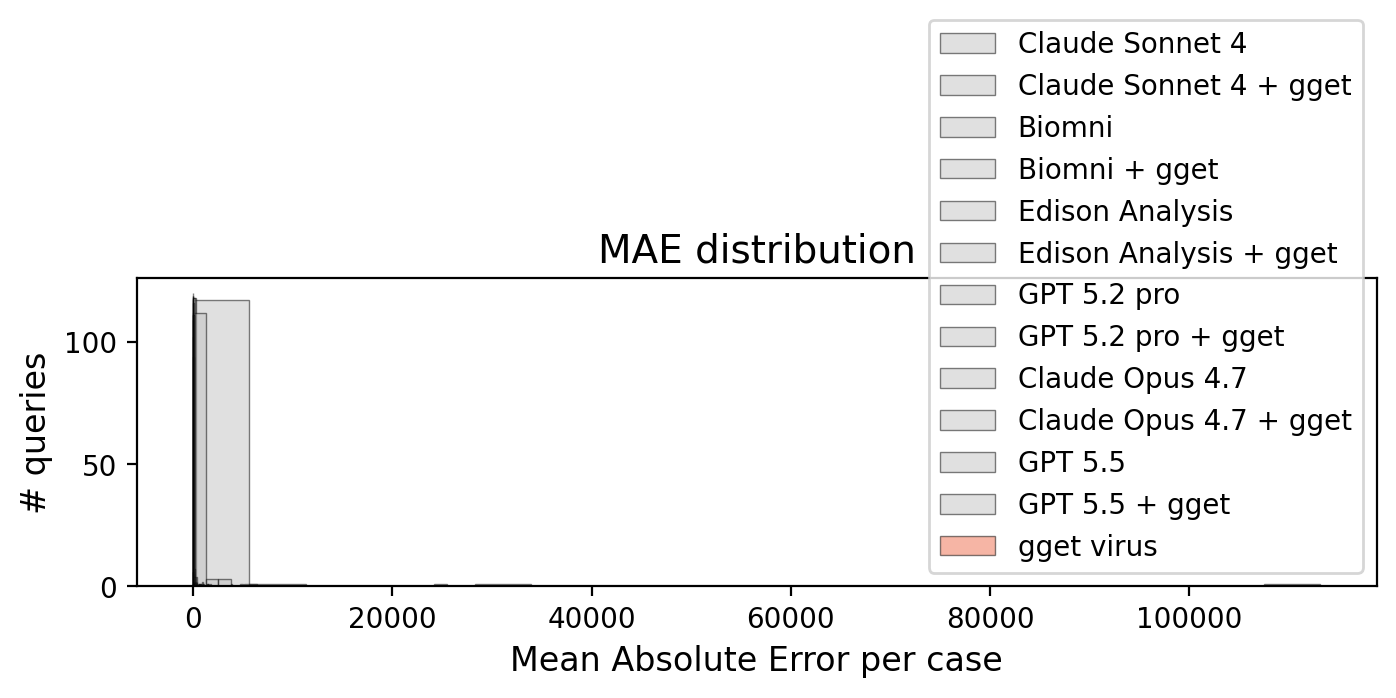

In [37]:
# On average, how many counts off is the model per case?
fig, ax = plt.subplots(figsize=FIGSIZE)
for name in TECHNOLOGIES:
    ax.hist(metrics[name]["mae"], bins=20,
            edgecolor="black", lw=0.5, alpha=0.5, color=COLORS[name], label=name)
ax.set_xlabel("Mean Absolute Error per case", fontsize=FONTSIZE)
ax.set_ylabel("# queries", fontsize=FONTSIZE)
ax.set_title("MAE distribution", fontsize=FONTSIZE + 2)
ax.tick_params(labelsize=FONTSIZE - 2)
ax.legend(fontsize=FONTSIZE - 2)
fig.tight_layout()

/tmp/ipykernel_2360916/694911253.py:12: UserWarning: Tight layout not applied. The bottom and top margins cannot be made large enough to accommodate all Axes decorations.
  fig.tight_layout()


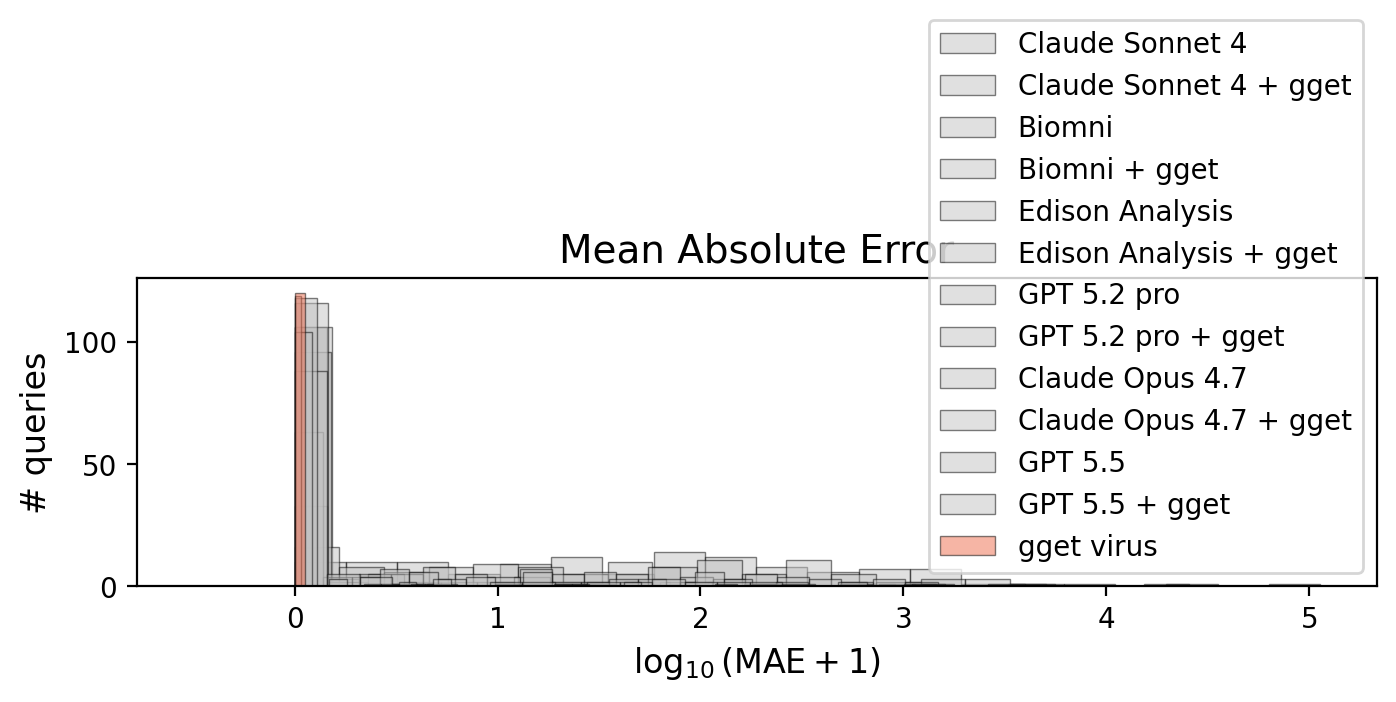

In [38]:
# On average, what order of magnitude is the error?
fig, ax = plt.subplots(figsize=FIGSIZE)
for name in TECHNOLOGIES:
    ax.hist(np.log10(metrics[name]["mae"] + 1.0), bins=20,
            edgecolor="black", lw=0.5, alpha=0.5, color=COLORS[name], label=name)
ax.set_xlabel(r"$\log_{10}(\mathrm{MAE} + 1)$", fontsize=FONTSIZE)
ax.set_ylabel("# queries", fontsize=FONTSIZE)
ax.set_title("Mean Absolute Error", fontsize=FONTSIZE + 2)
ax.tick_params(labelsize=FONTSIZE - 2)
# ax.set_xlim(-0.05)
ax.legend(fontsize=FONTSIZE - 2)
fig.tight_layout()

/tmp/ipykernel_2360916/2409185157.py:10: UserWarning: Tight layout not applied. The bottom and top margins cannot be made large enough to accommodate all Axes decorations.
  fig.tight_layout()


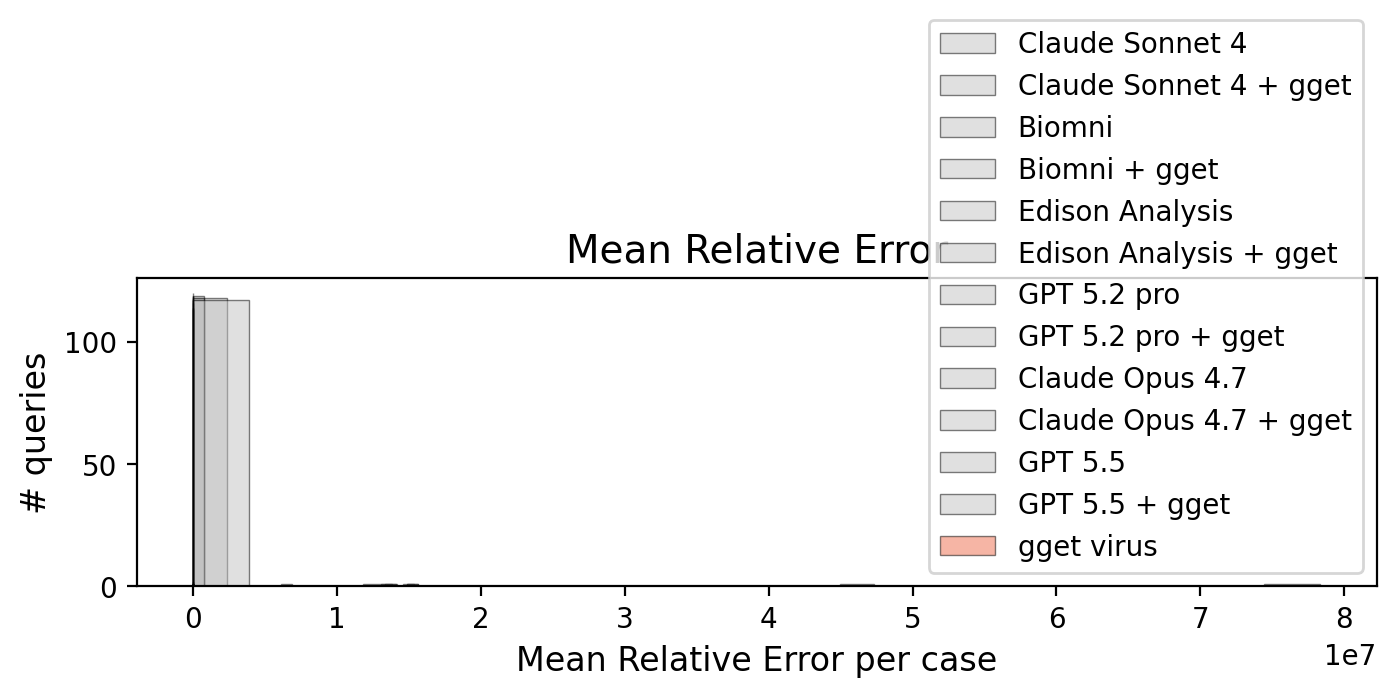

In [39]:
fig, ax = plt.subplots(figsize=FIGSIZE)
for name in TECHNOLOGIES:
    ax.hist(metrics[name]["mre"], bins=20,
            edgecolor="black", lw=0.5, alpha=0.5, color=COLORS[name], label=name)
ax.set_xlabel("Mean Relative Error per case", fontsize=FONTSIZE)
ax.set_ylabel("# queries", fontsize=FONTSIZE)
ax.set_title("Mean Relative Error", fontsize=FONTSIZE + 2)
ax.tick_params(labelsize=FONTSIZE - 2)
ax.legend(fontsize=FONTSIZE - 2)
fig.tight_layout()

# Overall score

/tmp/ipykernel_2360916/212801004.py:11: UserWarning: Tight layout not applied. The bottom and top margins cannot be made large enough to accommodate all Axes decorations.
  fig.tight_layout()


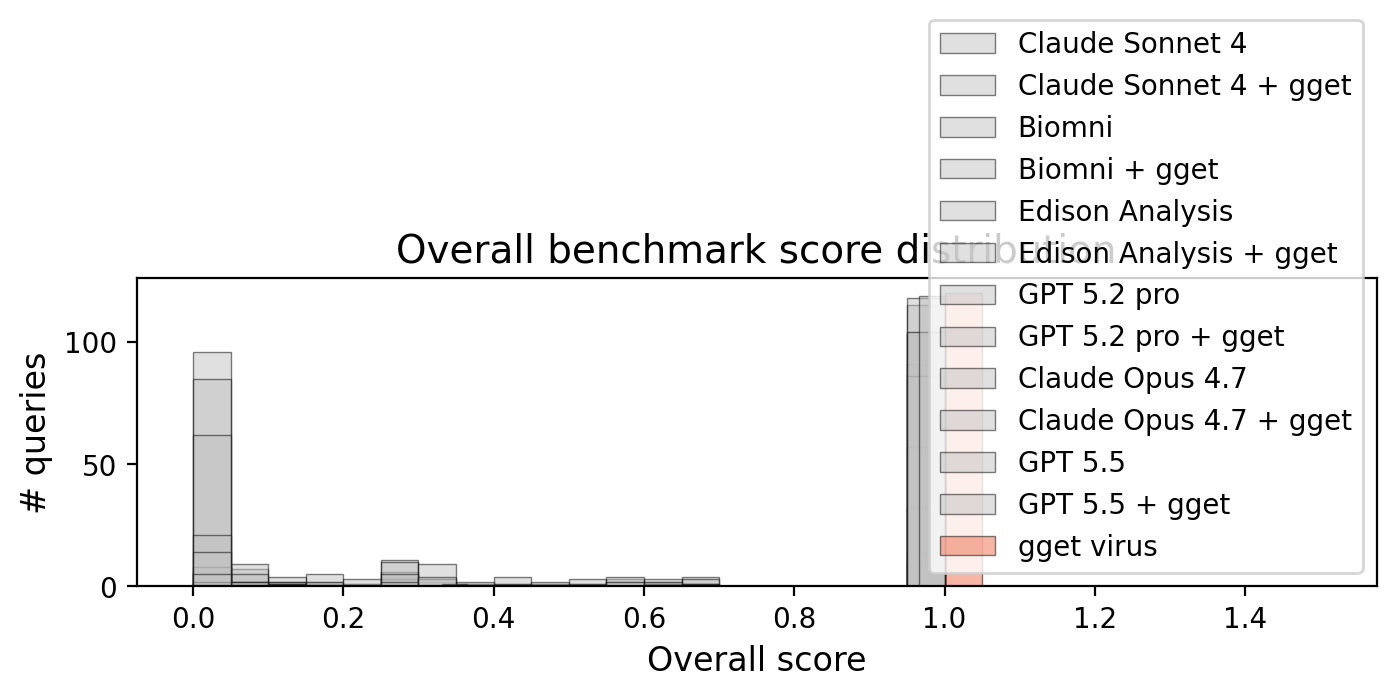

In [40]:
fig, ax = plt.subplots(figsize=FIGSIZE)
for name in TECHNOLOGIES:
    ax.hist(metrics[name]["score"], bins=20,
            edgecolor="black", lw=0.5, alpha=0.5, color=COLORS[name], label=name)
ax.set_xlabel("Overall score", fontsize=FONTSIZE)
ax.set_ylabel("# queries", fontsize=FONTSIZE)
ax.set_title("Overall benchmark score distribution", fontsize=FONTSIZE + 2)
ax.tick_params(labelsize=FONTSIZE - 2)
# ax.set_xlim(0, 1)
ax.legend(fontsize=FONTSIZE - 2)
fig.tight_layout()